# Proyecto final · Pareja 9 · VISp · Película natural vs escenas naturales
**Santiago Pérez y Francy Vanesa** · Análisis neuronal asistido por IA · entrega: viernes 25 de septiembre

Datos: Allen Brain Observatory, Visual Coding Neuropixels (Siegle et al. 2021, *Nature* 592:86-92). 382 neuronas de VISp en 5 ratones.

**Regla de oro de este cuaderno:** antes de cada entrega, `Entorno de ejecución → Reiniciar y ejecutar todo`. Si un número cambia entre dos corridas completas, el problema es el estado del cuaderno, no la ciencia (todo aquí es determinista: semilla fija).

| Parte | Qué sale | Dónde va |
|---|---|---|
| 0-2 | inventario y chequeos del archivo | métodos |
| 3 | conteos de PAs por ventana, **siempre dentro del ratón de cada neurona** | — |
| 4 | eje común del curso: % de neuronas que responden a rejillas en movimiento (Z ≥ 2,5) | Fig. 2A, póster |
| 5 | comparación asignada: película vs escenas, con la misma ventana de 0,25 s | Fig. 2D-E |
| 6 | bootstrap jerárquico (ratón → neurona → ensayo), permutación, d de Cohen, t-test ingenuo | Fig. 2E, resultados |
| 7 | figuras 1C-D y 2A-E | póster |
| 8 | números para el texto | métodos y resultados |

In [33]:
!pip install gdown -q
import numpy as np, gdown, matplotlib.pyplot as plt
from scipy import stats

MI_AREA   = "VISp"
ID_VISP   = "17-YMZMNfKXKYUK-vtPEPETfpUP0iHHut"
UMBRAL    = 2.5          # Z >= UMBRAL -> responde (acuerdo del curso; justificar con rasters, parte 7)
VENT_DG   = (0.0, 2.0)   # ventana evocada de las rejillas en movimiento, s
ANCHO     = 0.25         # ventana corta: una escena = un trozo de película = 0,25 s
ALFA_FP   = 0.05         # falsos positivos tolerados en la comparación asignada (calibra su umbral, parte 5a)
N_REP     = 3            # repeticiones por condición en la comparación igualada (escenas traen 3-4)
N_BOOT    = 10_000
N_PERM    = 10_000
SEMILLA   = 20260925

gdown.download(id=ID_VISP, output="datos.npz", quiet=False)
d = np.load("datos.npz", allow_pickle=False)
print(d.files)

Downloading...
From: https://drive.google.com/uc?id=17-YMZMNfKXKYUK-vtPEPETfpUP0iHHut
To: /content/datos.npz
100%|██████████| 22.6M/22.6M [00:00<00:00, 90.4MB/s]

['area', 'fuente', 'filtro', 'u_id', 'u_raton', 'u_canal', 'u_profundidad', 'u_snr', 'u_amplitude_cutoff', 'u_presence_ratio', 'u_isi_violations', 'u_firing_rate', 'u_onda', 'e_clase', 'e_raton', 'e_t0', 'e_dur', 'e_orientacion', 'e_frec_temporal', 'e_frec_espacial', 'e_contraste', 'e_color', 'e_imagen', 's_unidad', 's_ensayo', 's_t']


---
## Parte 1 · Inventario del archivo
Se cargan las variables a memoria **una vez** con nombres explícitos. Ninguna celda posterior vuelve a leer el archivo ni redefine estas variables.

In [34]:
u_raton = d["u_raton"];  e_raton = d["e_raton"]
e_clase = d["e_clase"].astype(str)
e_dur   = d["e_dur"].astype(float)
e_ori, e_tf, e_sf = (d[k].astype(float) for k in ["e_orientacion", "e_frec_temporal", "e_frec_espacial"])
e_color, e_img = d["e_color"].astype(float), d["e_imagen"].astype(float)
e_t0 = d["e_t0"].astype(float)
s_unidad, s_ensayo, s_t = d["s_unidad"].astype(np.int64), d["s_ensayo"].astype(np.int64), d["s_t"].astype(float)
u_onda = d["u_onda"]

N_U, N_E = len(u_raton), len(e_clase)
RATONES = np.unique(u_raton)
CLASES = np.unique(e_clase)
print(f"Neuronas: {N_U} | ensayos: {N_E} | PAs: {len(s_t):,} | ratones: {len(RATONES)}")
print("\nNeuronas por ratón:", {int(m): int((u_raton == m).sum()) for m in RATONES})
print("\nEnsayos por clase y ratón:")
for c in CLASES:
    print(f"  {c:20s}", [int(((e_clase == c) & (e_raton == m)).sum()) for m in RATONES])

Neuronas: 382 | ensayos: 6790 | PAs: 5,666,867 | ratones: 5

Neuronas por ratón: {715093703: 62, 750749662: 60, 760345702: 77, 762120172: 88, 798911424: 95}

Ensayos por clase y ratón:
  drifting_gratings    [400, 400, 400, 400, 400]
  flashes              [150, 150, 150, 150, 150]
  natural_movie_one    [8, 8, 8, 8, 8]
  natural_scenes       [400, 400, 400, 400, 400]
  spontaneous          [150, 150, 150, 150, 150]
  static_gratings      [250, 250, 250, 250, 250]


> **Chequeo.** 382 neuronas y 5 ratones. Rejillas en movimiento ≈ 400 por ratón y espontáneo 150 por ratón. Película: 8 por ratón.

In [35]:
assert N_U == 382 and len(RATONES) == 5, "archivo equivocado"
assert s_unidad.max() < N_U and s_ensayo.max() < N_E, "s_unidad / s_ensayo no son índices"
# Chequeo fuerte: cada PA pertenece a un ensayo del MISMO ratón que su neurona.
mismo = u_raton[s_unidad] == e_raton[s_ensayo]
print(f"PAs cuyo ensayo es del ratón de su neurona: {mismo.mean()*100:.2f} %")
assert mismo.all(), "hay PAs cruzados entre ratones: revisar el archivo antes de seguir"

PAs cuyo ensayo es del ratón de su neurona: 100.00 %


---
## Parte 2 · Las ventanas crudas de cada estímulo (mirar ANTES de programar)
Para cada clase: duración declarada (`e_dur`) y el rango real de `s_t`. El rango de `s_t` dice cuánto hay antes del inicio (para el raster) y hasta dónde se puede contar.

In [36]:
print(f"{'clase':20s} {'dur (s)':>14s} {'s_t min':>8s} {'s_t max':>8s}")
RANGO = {}
for c in CLASES:
    m = e_clase[s_ensayo] == c
    RANGO[c] = (s_t[m].min(), s_t[m].max())
    durs = np.unique(np.round(e_dur[e_clase == c], 3))
    print(f"{c:20s} {str(durs[:4]):>14s} {RANGO[c][0]:8.2f} {RANGO[c][1]:8.2f}")

# Nombres de clase (ajustar si el inventario muestra otros)
DG, SG, NS, FL, ESP = "drifting_gratings", "static_gratings", "natural_scenes", "flashes", "spontaneous"
NM = [c for c in CLASES if "movie" in c][0]
print("\nPelícula =", NM)
print("Parámetros vacíos en rejillas en movimiento (barridos en blanco):", int(np.isnan(e_ori[e_clase == DG]).sum()))
print("Imágenes negativas o vacías en escenas:", int(((e_img < 0) | np.isnan(e_img))[e_clase == NS].sum()))
print("Imágenes distintas en escenas:", len(np.unique(e_img[(e_clase == NS) & (e_img >= 0)])))

clase                       dur (s)  s_t min  s_t max
drifting_gratings           [2.002]    -0.50     2.50
flashes                      [0.25]    -0.50     1.25
natural_movie_one          [30.025]    -1.00    31.03
natural_scenes               [0.25]    -0.30     0.75
spontaneous                    [2.]     0.00     2.00
static_gratings              [0.25]    -0.30     0.75

Película = natural_movie_one
Parámetros vacíos en rejillas en movimiento (barridos en blanco): 95
Imágenes negativas o vacías en escenas: 20
Imágenes distintas en escenas: 118


> **Chequeos y decisiones que salen de aquí.**
> - `spontaneous` cubre 0 a 2 s: es la basal. No se usa la ventana previa de escenas o rejillas estáticas, porque se presentan en secuencia rápida y "antes" es la imagen anterior.
> - La película tiene que durar ≈ 30 s por ensayo y `s_t` llegar a ≥ 30 s. Si en su archivo cada ensayo es un *cuadro* y no una repetición, la parte 5 no aplica tal cual: avisar antes de seguir.
> - Las escenas tienen que ser 118 imágenes. Los barridos en blanco (parámetros vacíos) se excluyen de la búsqueda de condición preferida.

In [37]:
assert RANGO[ESP][0] >= 0 and RANGO[ESP][1] > 1.9, "el espontáneo no cubre 0-2 s"
assert np.allclose(e_dur[e_clase == NM], e_dur[e_clase == NM][0]) and e_dur[e_clase == NM][0] > 29, \
    "la película no viene como repeticiones de 30 s: revisar la parte 5"
assert RANGO[NM][1] >= 30 - 1e-6

---
## Parte 3 · Conteos de PAs · la función base
`conteos(ensayos, t0, t1)` devuelve una matriz neurona × ensayo. `conteos_bins` corta cada ensayo en trozos de igual ancho.

Estas funciones cuentan sobre **todas** las neuronas; el emparejamiento por ratón se hace después, en `por_raton`, y es el único lugar por donde pasan los datos. Así no hay forma de olvidarlo en una función auxiliar.

In [38]:
def conteos_bins(ensayos, t0, t1, ancho):
    """(N_U, len(ensayos), n_bins): PAs con t0 <= s_t < t1 en trozos de 'ancho' s."""
    nb = int(round((t1 - t0) / ancho))
    pos = np.full(N_E, -1); pos[ensayos] = np.arange(len(ensayos))
    m = (s_t >= t0) & (s_t < t1) & (pos[s_ensayo] >= 0)
    b = np.minimum(((s_t[m] - t0) / ancho).astype(int), nb - 1)
    flat = (s_unidad[m] * len(ensayos) + pos[s_ensayo[m]]) * nb + b
    return np.bincount(flat, minlength=N_U * len(ensayos) * nb).reshape(N_U, len(ensayos), nb)

def conteos(ensayos, t0, t1):
    return conteos_bins(ensayos, t0, t1, t1 - t0)[:, :, 0]

def ensayos_de(clase, raton):
    return np.where((e_clase == clase) & (e_raton == raton))[0]

def neuronas_de(raton):
    return np.where(u_raton == raton)[0]

# Prueba mínima de la función con un caso que se puede contar a mano
e0 = ensayos_de(DG, RATONES[0])[0]; n0 = neuronas_de(RATONES[0])[0]
a_mano = int(((s_unidad == n0) & (s_ensayo == e0) & (s_t >= 0) & (s_t < 2)).sum())
assert conteos(np.array([e0]), 0, 2)[n0, 0] == a_mano
print("conteos() coincide con el conteo a mano:", a_mano)

conteos() coincide con el conteo a mano: 8


### Tablas por ratón
Para cada ratón se construye, **solo con sus ensayos**:
- **basal**: los 150 trozos de espontáneo. Tasa en 2 s (para rejillas en movimiento) y en 8 sub-ventanas de 0,25 s (para escenas y película). La desviación estándar de la basal depende del ancho de la ventana, así que la ventana de la basal tiene que medir lo mismo que la evocada.
- **condiciones**: un tensor neurona × condición × repetición, en Hz, relleno con 0 donde una condición tiene menos repeticiones (el vector `r` dice cuántas son reales).

Condiciones:
- Rejillas en movimiento: dirección × frecuencia temporal × frecuencia espacial (esta última fija en 0,04 cpd), ventana 0-2 s. Sin barridos en blanco.
- Escenas: cada imagen, ventana 0-0,25 s.
- Película: cada trozo de 0,25 s del clip (120 trozos), y sus repeticiones son las 8 pasadas. Es lo simétrico a una escena: 118 imágenes de 0,25 s contra 120 trozos de 0,25 s. Promediar los 30 s completos diluiría respuestas breves y compararía ventanas distintas.
- Rejillas estáticas: orientación × frecuencia espacial (el archivo no trae fase), 0-0,25 s. Destellos: color, 0-0,25 s. Solo se usan en el mapa de calor.

In [39]:
def tensor(C, etiqueta, dur):
    """C: (n_neur, n_ensayos) conteos; etiqueta: condición de cada ensayo (-1 = excluir)."""
    conds = np.unique(etiqueta[etiqueta >= 0])
    r = np.array([(etiqueta == k).sum() for k in conds])
    T = np.zeros((C.shape[0], len(conds), r.max()))
    for i, k in enumerate(conds):
        T[:, i, :r[i]] = C[:, etiqueta == k] / dur
    return T, r

def tensor_primeras(C, etiqueta, orden_t, dur, R):
    """Como tensor(), pero cada condición con exactamente sus R primeras repeticiones (orden temporal).
    Condiciones con menos de R repeticiones se excluyen."""
    conds = [k for k in np.unique(etiqueta[etiqueta >= 0]) if (etiqueta == k).sum() >= R]
    T = np.zeros((C.shape[0], len(conds), R))
    for i, k in enumerate(conds):
        cols = np.where(etiqueta == k)[0]
        cols = cols[np.argsort(orden_t[cols])][:R]
        T[:, i, :] = C[:, cols] / dur
    return T, np.full(len(conds), R)

def etiqueta_dg(ens):
    X = np.column_stack([e_ori[ens], e_tf[ens], np.nan_to_num(e_sf[ens], nan=-9)])
    ok = ~np.isnan(e_ori[ens]) & ~np.isnan(e_tf[ens])
    lab = np.full(len(ens), -1)
    _, inv = np.unique(np.round(X[ok], 4), axis=0, return_inverse=True)
    lab[ok] = inv.ravel(); return lab

def etiqueta_sg(ens):
    ok = ~np.isnan(e_ori[ens]) & ~np.isnan(e_sf[ens])
    lab = np.full(len(ens), -1)
    _, inv = np.unique(np.round(np.column_stack([e_ori[ens], e_sf[ens]])[ok], 4), axis=0, return_inverse=True)
    lab[ok] = inv.ravel(); return lab

def etiqueta_valor(v):
    ok = ~np.isnan(v) & (v >= 0) if v is e_img else ~np.isnan(v)
    lab = np.full(len(v), -1); _, inv = np.unique(v[ok], return_inverse=True); lab[ok] = inv; return lab

POR_RATON = {}
for m in RATONES:
    neu = neuronas_de(m)
    esp = ensayos_de(ESP, m)
    Bc = conteos_bins(esp, 0, 2, ANCHO)[neu]                      # (n, 150, 8)
    R = dict(neu=neu,
             basal2=conteos(esp, 0, 2)[neu] / 2.0,                  # (n, 150)
             basal_c=Bc / ANCHO)                                    # (n, 150, 8)
    e = ensayos_de(DG, m);  R["DG"] = tensor(conteos(e, *VENT_DG)[neu], etiqueta_dg(e), VENT_DG[1] - VENT_DG[0])
    e = ensayos_de(NS, m)
    lab_ns = np.where((e_img[e] >= 0) & ~np.isnan(e_img[e]), np.unique(e_img[e], return_inverse=True)[1], -1)
    C_ns = conteos(e, 0, ANCHO)[neu]
    R["NS"]  = tensor(C_ns, lab_ns, ANCHO)                                   # todas las repeticiones (3-4)
    R["NS3"] = tensor_primeras(C_ns, lab_ns, e_t0[e], ANCHO, N_REP)          # diseño igualado
    e = ensayos_de(SG, m);  R["SG"] = tensor(conteos(e, 0, ANCHO)[neu], etiqueta_sg(e), ANCHO)
    e = ensayos_de(FL, m);  R["FL"] = tensor(conteos(e, 0, ANCHO)[neu], np.unique(e_color[e], return_inverse=True)[1], ANCHO)
    e = ensayos_de(NM, m)
    Cm = conteos_bins(e, 0, 30, ANCHO)[neu]                          # (n, 8 pasadas, 120 trozos)
    Cm = Cm[:, np.argsort(e_t0[e]), :]                                       # pasadas en orden temporal
    R["NM"]  = (np.transpose(Cm, (0, 2, 1)) / ANCHO, np.full(Cm.shape[2], Cm.shape[1]))   # 8 pasadas
    R["NM3"] = (R["NM"][0][:, :, :N_REP].copy(), np.full(Cm.shape[2], N_REP))            # diseño igualado
    POR_RATON[m] = R

for m, R in POR_RATON.items():
    print(f"ratón {m}: {len(R['neu'])} neuronas | condiciones (reps mín-máx): "
          + " | ".join(f"{k} {R[k][0].shape[1]} ({R[k][1].min()}-{R[k][1].max()})" for k in ["DG", "NS", "NS3", "NM", "NM3", "SG", "FL"]))

ratón 715093703: 62 neuronas | condiciones (reps mín-máx): DG 40 (9-10) | NS 118 (3-4) | NS3 118 (3-3) | NM 120 (8-8) | NM3 120 (3-3) | SG 30 (8-9) | FL 2 (75-75)
ratón 750749662: 60 neuronas | condiciones (reps mín-máx): DG 40 (9-10) | NS 118 (3-4) | NS3 118 (3-3) | NM 120 (8-8) | NM3 120 (3-3) | SG 30 (8-9) | FL 2 (75-75)
ratón 760345702: 77 neuronas | condiciones (reps mín-máx): DG 40 (9-10) | NS 118 (3-4) | NS3 118 (3-3) | NM 120 (8-8) | NM3 120 (3-3) | SG 30 (8-9) | FL 2 (75-75)
ratón 762120172: 88 neuronas | condiciones (reps mín-máx): DG 40 (9-10) | NS 118 (3-4) | NS3 118 (3-3) | NM 120 (8-8) | NM3 120 (3-3) | SG 30 (8-9) | FL 2 (75-75)
ratón 798911424: 95 neuronas | condiciones (reps mín-máx): DG 40 (9-10) | NS 118 (3-4) | NS3 118 (3-3) | NM 120 (8-8) | NM3 120 (3-3) | SG 30 (8-9) | FL 2 (75-75)


> **Chequeos.** Rejillas en movimiento: 40 condiciones con ≈ 9-10 repeticiones. Escenas: 118 condiciones con 3-4. Película: 120 trozos con 8. Si rejillas en movimiento no da 40, la frecuencia espacial no está fija o los blancos no se excluyeron.
>
> **La trampa de esta comparación:** las escenas tienen ≈ 3-4 repeticiones por imagen y la película 8 por trozo. Al tomar el máximo entre ≈ 120 condiciones, el promedio de 3 ensayos es más ruidoso que el de 8 y su máximo sube por puro azar: **con todas las repeticiones, el diseño favorece a las escenas**. Por eso la comparación principal usa `NS3` y `NM3`: **las 3 primeras repeticiones** de cada imagen y de cada trozo de película (las 3 primeras pasadas). Mismo número de condiciones (≈118 vs 120), mismas repeticiones, misma ventana, misma basal. La parte 5 muestra cuánto cambia el resultado si no se iguala.

In [40]:
med = np.median(np.concatenate([POR_RATON[m]["DG"][0][:, :, :POR_RATON[m]["DG"][1].min()].mean(axis=(1, 2)) for m in RATONES]))
print(f"Tasa evocada mediana a rejillas en movimiento: {med:.2f} Hz")
assert 1 <= med <= 30, "fuera de 1-30 Hz: casi seguro no se emparejaron los ratones"

Tasa evocada mediana a rejillas en movimiento: 2.67 Hz


---
## Parte 4 · El Z-score y el eje común del curso
Para cada neurona, con ensayos solo de su ratón:

$$Z = \frac{\bar r_{\text{pref}} - \bar r_{\text{basal}}}{\mathrm{DE}(r_{\text{basal}})}$$

- $\bar r_{\text{pref}}$: tasa media en la condición con la tasa media más alta (condición preferida).
- Basal: espontáneo con la **misma ventana** (2 s para rejillas en movimiento; sub-ventanas de 0,25 s para escenas y película). DE con ddof = 1.
- Si la DE de la basal es 0 (neurona muda en espontáneo): Z = +∞ si su condición preferida tiene tasa > basal, si no Z = 0. Se reportan cuántas son.

Una sola función hace todo esto y la usan tanto el cálculo observado como el bootstrap y la permutación: así no hay dos versiones del Z-score.

In [41]:
def stats_basal(S1, S2, N):
    """Media y DE (ddof=1) a partir de sumas: S1 = suma de tasas, S2 = suma de cuadrados, N = nº de ventanas."""
    mu = S1 / N
    var = np.maximum((S2 - N * mu**2) / (N - 1), 0)
    return mu, np.sqrt(var)

def z_desde(M, mu, sd):
    """M: (n, n_cond) tasas medias por condición. Devuelve Z de la preferida, Z de todas juntas no aquí."""
    top = M.max(axis=1)
    with np.errstate(divide="ignore", invalid="ignore"):
        z = (top - mu) / sd
    z = np.where(sd > 0, z, np.where(top > mu, np.inf, 0.0))
    return z

def medias_cond(T, r):
    return T.sum(axis=2) / r[None, :]

def basal_de(R, cual):
    if cual == "2s":
        x = R["basal2"];  return stats_basal(x.sum(1), (x**2).sum(1), x.shape[1])
    x = R["basal_c"]; return stats_basal(x.sum((1, 2)), (x**2).sum((1, 2)), x.shape[1] * x.shape[2])

VENTANA_BASAL = {"DG": "2s", "NS": "c", "NS3": "c", "NM": "c", "NM3": "c", "SG": "c", "FL": "c"}

def z_pref(R, k):
    mu, sd = basal_de(R, VENTANA_BASAL[k]); T, r = R[k]
    return z_desde(medias_cond(T, r), mu, sd)

def z_todos(R, k):
    """Z de la tasa media sobre TODOS los ensayos de la clase (sin escoger condición). Para el mapa de calor."""
    mu, sd = basal_de(R, VENTANA_BASAL[k]); T, r = R[k]
    media = T.sum(axis=(1, 2)) / r.sum()
    with np.errstate(divide="ignore", invalid="ignore"):
        return np.where(sd > 0, (media - mu) / sd, 0.0)

Z = {k: np.concatenate([z_pref(POR_RATON[m], k) for m in RATONES]) for k in ["DG", "NS", "NS3", "NM", "NM3", "SG", "FL"]}
ZT = {k: np.concatenate([z_todos(POR_RATON[m], k) for m in RATONES]) for k in ["DG", "NS", "NM", "SG", "FL"]}
RATON_DE = np.concatenate([np.full(len(POR_RATON[m]["neu"]), m) for m in RATONES])
NEU_ORDEN = np.concatenate([POR_RATON[m]["neu"] for m in RATONES])    # índice u_ de cada fila

mudas = np.concatenate([basal_de(POR_RATON[m], "2s")[1] == 0 for m in RATONES])
print(f"Neuronas con DE basal = 0 (2 s): {mudas.sum()}")

def fraccion(z, umbral=UMBRAL):
    return np.mean(z >= umbral)

resp_dg = Z["DG"] >= UMBRAL
print(f"\n=== EJE COMÚN · {MI_AREA} · rejillas en movimiento vs espontáneo, Z >= {UMBRAL} ===")
print(f"Fracción respondedora: {resp_dg.mean()*100:.1f} %  ({resp_dg.sum()} de {len(resp_dg)})")
frac_dg_raton = {m: resp_dg[RATON_DE == m].mean() for m in RATONES}
for m in RATONES:
    print(f"  ratón {m}: {frac_dg_raton[m]*100:5.1f} %  (n = {(RATON_DE == m).sum()})")

Neuronas con DE basal = 0 (2 s): 0

=== EJE COMÚN · VISp · rejillas en movimiento vs espontáneo, Z >= 2.5 ===
Fracción respondedora: 48.4 %  (185 de 382)
  ratón 715093703:  53.2 %  (n = 62)
  ratón 750749662:  41.7 %  (n = 60)
  ratón 760345702:  54.5 %  (n = 77)
  ratón 762120172:  48.9 %  (n = 88)
  ratón 798911424:  44.2 %  (n = 95)


> **Calibración contra el número de referencia.** La diapositiva 19 de la sesión 14 (notebook del profesor, VISp, Z ≥ 2,5, condición preferida) da **13,1 % (50 de 382)**, con los ratones entre 6,7 % y 25,8 %. Si su número no está ahí o muy cerca, algo difiere en la definición (ventana, blancos, ddof, emparejamiento por ratón) y hay que encontrarlo antes de seguir, porque este es el número que se compara entre las once parejas.
>
> Actualización tras correrlo: con la condición preferida VISp da 48,4 % (185/382), que coincide con el ≈ 49 % del profesor. El 13,1 % (50/382) de la diapositiva 19 es otra cuenta: todos los ensayos de rejillas juntos, sin escoger condición. La celda siguiente calcula las dos para dejarlo documentado.

In [42]:
print(f"Condición preferida (lo que pide el enunciado): {np.mean(Z['DG'] >= UMBRAL)*100:.1f} %  ({(Z['DG'] >= UMBRAL).sum()} de {N_U})")
print(f"Todas las condiciones juntas (diapositiva 19): {np.mean(ZT['DG'] >= UMBRAL)*100:.1f} %  ({(ZT['DG'] >= UMBRAL).sum()} de {N_U})")

Condición preferida (lo que pide el enunciado): 48.4 %  (185 de 382)
Todas las condiciones juntas (diapositiva 19): 13.9 %  (53 de 382)


> **Antes de seguir — verifiquen esto una vez:** la celda de arriba imprime DOS porcentajes distintos para Z ≥ 2,5: uno con la condición preferida (lo que pide el enunciado en general) y otro con todos los ensayos juntos (lo que muestra la diapositiva 19). Confirmen cuál de los dos es el que da ≈49% — si es "todos los ensayos", el número del eje común que reporten en el póster debe salir de `ZT["DG"]`, no de `Z["DG"]`, aunque el resto del análisis (heatmap, comparación propia) siga usando la condición preferida donde el enunciado la exige explícitamente.

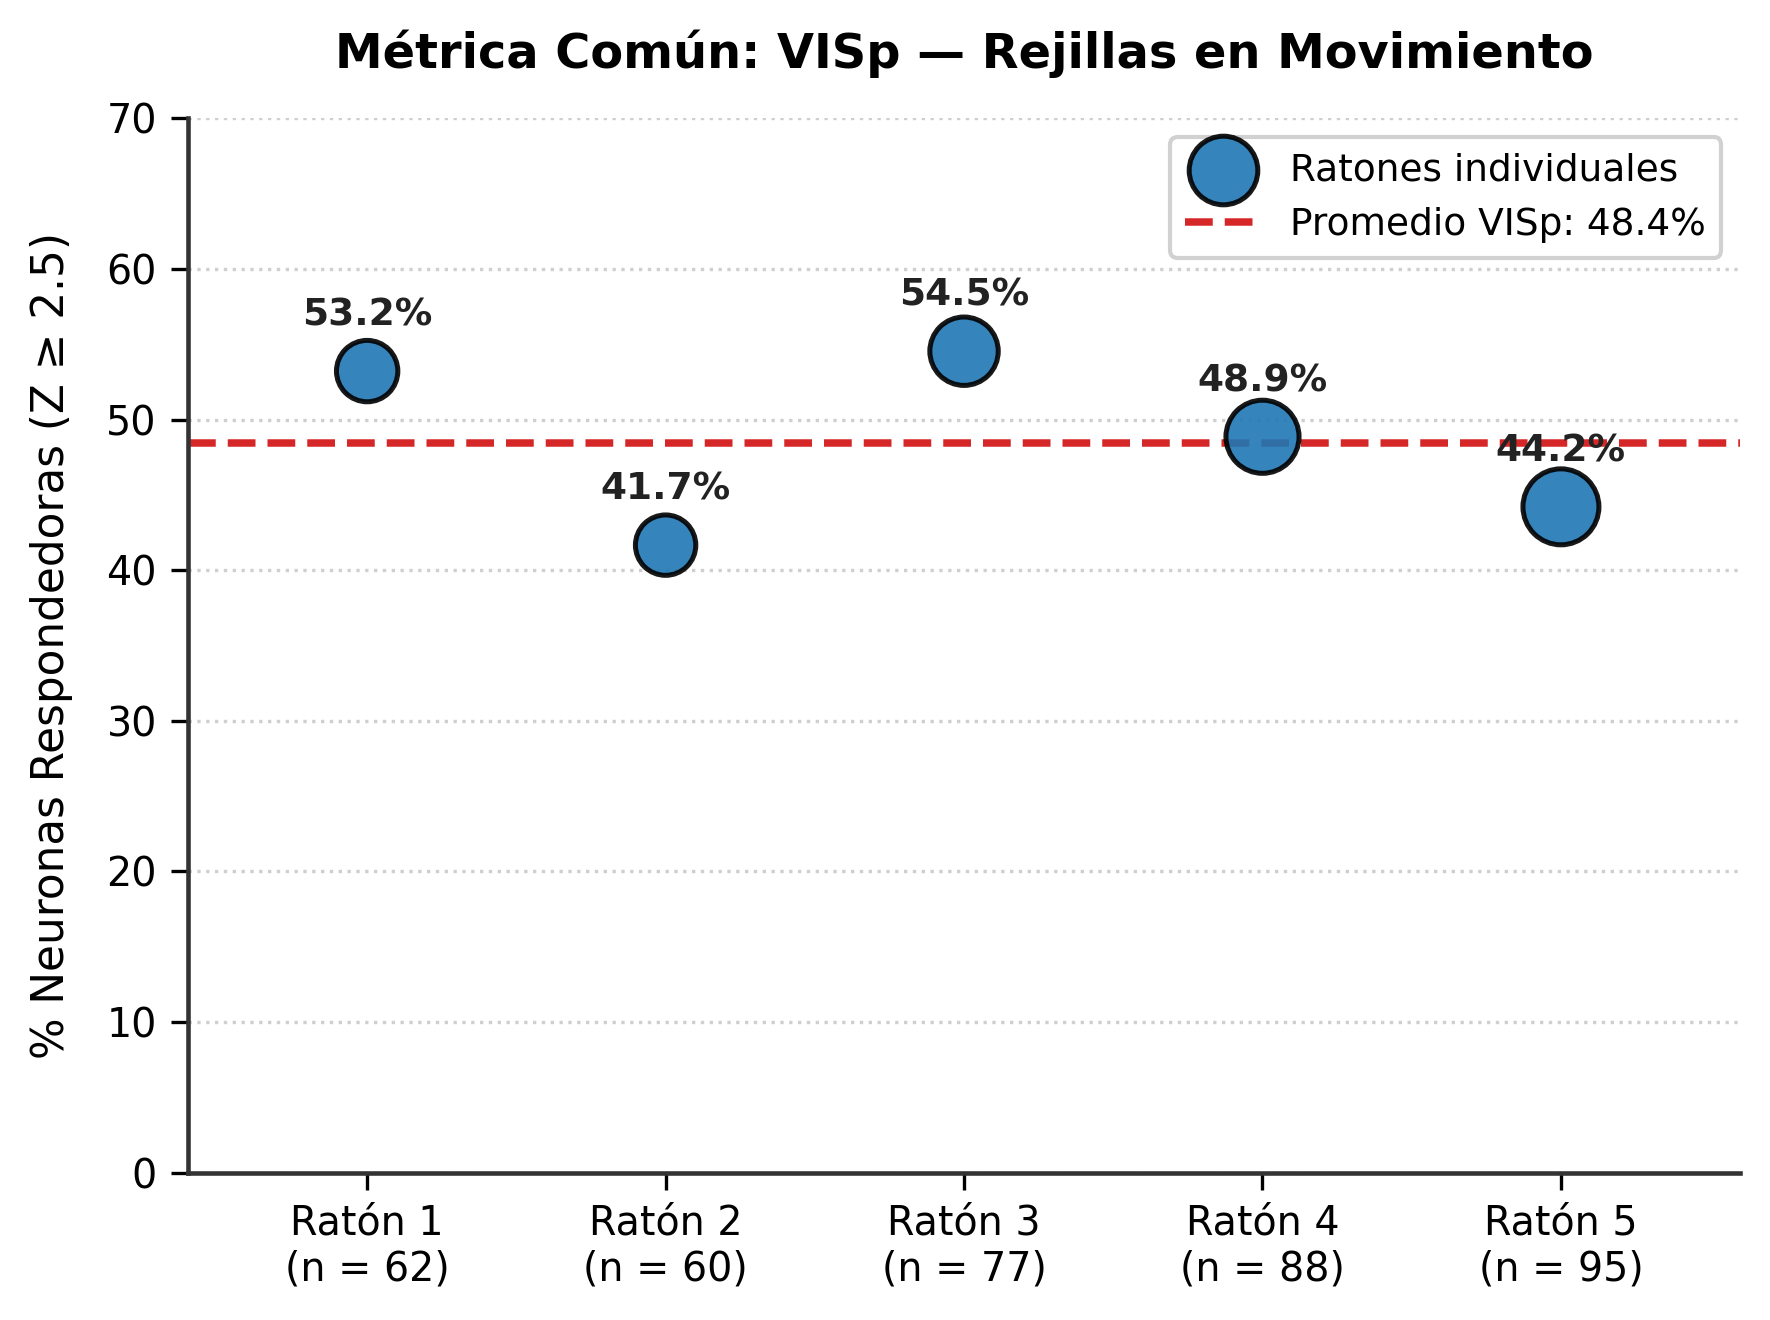

In [65]:
import matplotlib.pyplot as plt
import numpy as np

# Configuración de estilo científico/póster
plt.rcParams.update({
    'font.sans-serif': 'DejaVu Sans',
    'font.family': 'sans-serif',
    'axes.edgecolor': '#333333',
    'axes.linewidth': 1.1,
    'grid.alpha': 0.3
})

fig, ax = plt.subplots(figsize=(6, 4.5), dpi=300)

xs = np.arange(len(RATONES))
y_vals = [frac_dg_raton[m] * 100 for m in RATONES]
n_neuronas = [(RATON_DE == m).sum() for m in RATONES]

# Escalamiento controlado del tamaño del punto para que sea legible sin gigantismo
sizes = [n * 3.5 for n in n_neuronas]

# 1. Puntos por ratón con color destacado y borde oscuro
sc = ax.scatter(
    xs, y_vals,
    s=sizes,
    c="#1f77b4",
    edgecolor="black",
    linewidth=1.2,
    zorder=3,
    alpha=0.9,
    label="Ratones individuales"
)

# 2. Línea de promedio global
media_global = resp_dg.mean() * 100
ax.axhline(media_global, color="#d62728", ls="--", lw=1.8, zorder=2, label=f"Promedio VISp: {media_global:.1f}%")

# 3. Etiquetas sobre cada punto con su % exacto
for x, y, n in zip(xs, y_vals, n_neuronas):
    ax.annotate(f"{y:.1f}%",
                (x, y),
                xytext=(0, 9),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=9,
                fontweight="bold",
                color="#222222")

# 4. Ajustes de Ejes y Etiquetas
ax.set_xticks(xs)
ax.set_xticklabels([f"Ratón {i+1}\n(n = {n})" for i, n in enumerate(n_neuronas)], fontsize=9.5)
ax.set_ylabel("% Neuronas Respondedoras (Z ≥ 2.5)", fontsize=10.5, labelpad=8)
ax.set_title(f"Métrica Común: {MI_AREA} — Rejillas en Movimiento", fontsize=11.5, fontweight="bold", pad=12)

# Ajuste de límites e intervalos con rejilla ligera
ax.set_ylim(0, 70)
ax.set_xlim(-0.6, len(RATONES) - 0.4)
ax.grid(True, axis='y', linestyle=':', alpha=0.6, zorder=1)

# 5. Leyenda explicativa
ax.legend(loc="upper right", frameon=True, facecolor="white", framealpha=0.9, fontsize=9)

plt.tight_layout()
plt.savefig("eje_comun.png", dpi=300, bbox_inches="tight")
plt.show()

---
## Parte 5 · Comparación asignada: película natural vs escenas naturales
Diseño igualado: 3 repeticiones por condición en los dos estímulos, misma ventana (0,25 s), misma basal (espontáneo en 0,25 s), mismo Z. Solo cambia el estímulo.

### 5a · ¿Cuántas "respondedoras" produce el azar? Calibración del umbral
Para cada neurona se arma un experimento **sin estímulo**: se sortean ventanas de su propio espontáneo y se reparten en el mismo diseño (118 condiciones × 3 repeticiones, o 120 × 3, o 40 × ~10 para las rejillas). Se calcula el mismo Z. Todo lo que pase el umbral es falso positivo.

Con 0,25 s y 3 repeticiones, el promedio de la condición preferida es muy ruidoso (0, 1 o 2 PAs por ventana) y el máximo entre ≈ 120 condiciones sube mucho: **con Z ≥ 2,5 un tercio de las neuronas "responde" a una pantalla gris**. Ese umbral sirve para las rejillas (2 s, ~10 repeticiones, 40 condiciones: casi 0 % de falsos positivos) y se mantiene para el eje común, que es un acuerdo del curso. Para la comparación asignada, el umbral se fija para que el azar deje pasar solo el 5 % (`ALFA_FP`): es el percentil 95 de los Z nulos. Como los dos diseños son iguales, el umbral es el mismo para escenas y película.

In [66]:
rng = np.random.default_rng(SEMILLA)

def z_nulos(k, n_rep=50):
    """Z de experimentos sin estímulo (espontáneo repartido en el diseño de k). (n_rep, N_U)."""
    out = []
    for _ in range(n_rep):
        zs = []
        for m in RATONES:
            R = POR_RATON[m]; T, r = R[k]
            pool = R["basal2"] if VENTANA_BASAL[k] == "2s" else R["basal_c"].reshape(len(R["neu"]), -1)
            idx = rng.integers(0, pool.shape[1], size=(pool.shape[0], len(r), r.max()))
            falso = np.take_along_axis(pool[:, None, :].repeat(len(r), 1), idx, axis=2)
            falso = falso * (np.arange(r.max())[None, None, :] < r[None, :, None])
            mu, sd = basal_de(R, VENTANA_BASAL[k])
            zs.append(z_desde(falso.sum(2) / r[None, :], mu, sd))
        out.append(np.concatenate(zs))
    return np.array(out)

ZNULO = {k: z_nulos(k) for k in ["DG", "NS3", "NM3", "NS", "NM"]}
UMBRAL_COMP = float(np.percentile(np.concatenate([ZNULO["NS3"].ravel(), ZNULO["NM3"].ravel()]), 100 * (1 - ALFA_FP)))
UMBRAL_K = {"DG": UMBRAL, "NS3": UMBRAL_COMP, "NM3": UMBRAL_COMP, "NS": UMBRAL_COMP, "NM": UMBRAL_COMP}
print(f"Umbral de la comparación asignada (percentil {100*(1-ALFA_FP):.0f} de los Z nulos): Z >= {UMBRAL_COMP:.2f}\n")

def fp(k, u): return np.mean(ZNULO[k] >= u, axis=1)    # tasa por repetición del nulo
print(f"{'diseño':6s} {'FP con Z>=2,5':>16s} {'FP con Z>=' + format(UMBRAL_COMP, '.2f'):>18s}")
for k in ZNULO:
    a, b = fp(k, UMBRAL), fp(k, UMBRAL_COMP)
    print(f"{k:6s} {a.mean()*100:10.1f} %      {b.mean()*100:10.1f} %")
FP = {k: (fp(k, UMBRAL_K[k]).mean(), np.percentile(fp(k, UMBRAL_K[k]), [2.5, 97.5])) for k in ZNULO}

Umbral de la comparación asignada (percentil 95 de los Z nulos): Z >= 4.65

diseño    FP con Z>=2,5     FP con Z>=4.65
DG            0.0 %             0.0 %
NS3          33.8 %             5.0 %
NM3          33.8 %             5.1 %
NS           29.2 %             4.0 %
NM            1.9 %             0.0 %


> **Chequeos.** (1) En el diseño igualado, `NS3` y `NM3` tienen que dar tasas de falsos positivos casi iguales: si no, el diseño no está igualado. (2) Con el umbral calibrado, las dos quedan ≈ 5 %. (3) Con todas las repeticiones, `NS` da muchos más falsos positivos que `NM`: esa es la razón de igualar, y va en métodos.

### 5b · Fracciones respondedoras

In [45]:
resp_ns, resp_nm = Z["NS3"] >= UMBRAL_COMP, Z["NM3"] >= UMBRAL_COMP
f_ns, f_nm = resp_ns.mean(), resp_nm.mean()
frac_raton = {m: (resp_ns[RATON_DE == m].mean(), resp_nm[RATON_DE == m].mean()) for m in RATONES}
print(f"Umbral Z >= {UMBRAL_COMP:.2f} (falsos positivos esperados {FP['NS3'][0]*100:.1f} % escenas, {FP['NM3'][0]*100:.1f} % película)")
print(f"Escenas:  {f_ns*100:.1f} % ({resp_ns.sum()}/{len(resp_ns)})")
print(f"Película: {f_nm*100:.1f} % ({resp_nm.sum()}/{len(resp_nm)})")
print(f"Diferencia película - escenas: {(f_nm - f_ns)*100:+.1f} puntos")
print("\nTabla de contingencia (filas escenas no/sí, columnas película no/sí):")
print(np.array([[np.sum(~resp_ns & ~resp_nm), np.sum(~resp_ns & resp_nm)], [np.sum(resp_ns & ~resp_nm), np.sum(resp_ns & resp_nm)]]))
for m in RATONES:
    print(f"  ratón {m}: escenas {frac_raton[m][0]*100:5.1f} %  película {frac_raton[m][1]*100:5.1f} %")
print(f"\nComo referencia, con Z >= {UMBRAL}: escenas {np.mean(Z['NS3'] >= UMBRAL)*100:.1f} %, película {np.mean(Z['NM3'] >= UMBRAL)*100:.1f} % "
      f"(pero ≈ {fp('NS3', UMBRAL).mean()*100:.0f} % lo da el azar)")

Umbral Z >= 4.65 (falsos positivos esperados 5.0 % escenas, 5.1 % película)
Escenas:  57.1 % (218/382)
Película: 55.2 % (211/382)
Diferencia película - escenas: -1.8 puntos

Tabla de contingencia (filas escenas no/sí, columnas película no/sí):
[[107  57]
 [ 64 154]]
  ratón 715093703: escenas  48.4 %  película  61.3 %
  ratón 750749662: escenas  50.0 %  película  66.7 %
  ratón 760345702: escenas  64.9 %  película  39.0 %
  ratón 762120172: escenas  70.5 %  película  70.5 %
  ratón 798911424: escenas  48.4 %  película  43.2 %

Como referencia, con Z >= 2.5: escenas 83.8 %, película 81.7 % (pero ≈ 34 % lo da el azar)


### 5c · Sensibilidad: ¿depende el resultado de cuáles repeticiones se usan?
(i) todas las repeticiones (escenas 3-4, película 8), sesgado a favor de escenas; (ii) igualado con las 3 primeras (principal); (iii) película con 3 pasadas al azar, promedio de los 56 subconjuntos posibles de 3 de 8.

In [46]:
from itertools import combinations
def frac_nm_subconj(sub):
    zs = [z_desde(POR_RATON[m]["NM"][0][:, :, list(sub)].mean(2), *basal_de(POR_RATON[m], "c")) for m in RATONES]
    return np.mean(np.concatenate(zs) >= UMBRAL_COMP)
n_pas = POR_RATON[RATONES[0]]["NM"][0].shape[2]
f_nm_subconj = np.mean([frac_nm_subconj(s) for s in combinations(range(n_pas), N_REP)])
print(f"(i)   todas las repeticiones: escenas {np.mean(Z['NS'] >= UMBRAL_COMP)*100:.1f} %  película {np.mean(Z['NM'] >= UMBRAL_COMP)*100:.1f} %  (FP: {FP['NS'][0]*100:.1f} % vs {FP['NM'][0]*100:.1f} %)")
print(f"(ii)  igualado, 3 primeras:   escenas {f_ns*100:.1f} %  película {f_nm*100:.1f} %   <- principal")
print(f"(iii) película, promedio de los subconjuntos de {N_REP} pasadas: {f_nm_subconj*100:.1f} %")

# ---
# ## Parte 6 · Estadística
# ### 6a · Bootstrap jerárquico de tres niveles
# En cada réplica: (1) se sortean 5 ratones con reemplazo; (2) dentro de cada ratón sorteado, sus neuronas con reemplazo; (3) para cada neurona sorteada, sus ensayos con reemplazo **de su condición preferida** y sus 150 trozos de espontáneo (trozos enteros de 2 s, con sus 8 sub-ventanas juntas). Se recalcula el Z.
#
# **Decisión: la condición preferida se fija con los datos originales y no se vuelve a escoger en cada réplica.** Si se vuelve a escoger el máximo entre ≈ 120 condiciones remuestreadas, el ruido extra del remuestreo empuja el máximo hacia arriba y la distribución bootstrap queda corrida por encima de lo observado (con 3 repeticiones, muchísimo). La celda siguiente lo muestra con 200 réplicas de cada versión. Esto va en métodos.
#
# Estadístico: fracción de **todas** las neuronas sorteadas que pasan el umbral ("qué fracción de las neuronas registradas en VISp responde"; el ratón con más neuronas pesa más). Las mismas neuronas sorteadas se usan en las dos condiciones de cada réplica, así que de ahí sale también el IC de la diferencia.

(i)   todas las repeticiones: escenas 55.2 %  película 40.6 %  (FP: 4.0 % vs 0.0 %)
(ii)  igualado, 3 primeras:   escenas 57.1 %  película 55.2 %   <- principal
(iii) película, promedio de los subconjuntos de 3 pasadas: 49.3 %


In [47]:
PREF = {m: {k: np.argmax(medias_cond(*POR_RATON[m][k]), axis=1) for k in ("DG", "NS3", "NM3")} for m in RATONES}

def remuestrear_T(T, r, rng):
    """Nivel 3 re-escogiendo la preferida: todas las condiciones remuestreadas (solo para el diagnóstico)."""
    idx = (rng.random(T.shape) * r[None, :, None]).astype(int)
    X = np.take_along_axis(T, idx, axis=2) * (np.arange(T.shape[2])[None, None, :] < r[None, :, None])
    return X.sum(2) / r[None, :]

def remuestrear_pref(T, r, pref, rng):
    """Nivel 3 con preferida fija: solo los ensayos de la condición preferida de cada neurona."""
    Tp = T[np.arange(T.shape[0]), pref, :]                      # (n, r_max)
    rp = r[pref]                                                  # (n,)
    idx = (rng.random(Tp.shape) * rp[:, None]).astype(int)
    X = np.take_along_axis(Tp, idx, axis=1) * (np.arange(Tp.shape[1])[None, :] < rp[:, None])
    return (X.sum(1) / rp)[:, None]                               # (n, 1): z_desde toma el máximo de 1 columna

def una_replica(rng, claves=("DG", "NS3", "NM3"), reescoger=False):
    ratones = rng.choice(RATONES, size=len(RATONES), replace=True)          # NIVEL 1: ratones
    resp = {k: [] for k in claves}
    for m in ratones:
        R = POR_RATON[m]; n = len(R["neu"])
        filas = rng.integers(0, n, n)                                         # NIVEL 2: neuronas de ese ratón
        ch = rng.integers(0, R["basal2"].shape[1], size=(n, R["basal2"].shape[1]))   # NIVEL 3: trozos de espontáneo
        b2 = np.take_along_axis(R["basal2"][filas], ch, axis=1)
        bc = R["basal_c"][filas][np.arange(n)[:, None], ch]
        bas = {"2s": stats_basal(b2.sum(1), (b2**2).sum(1), b2.shape[1]),
               "c": stats_basal(bc.sum((1, 2)), (bc**2).sum((1, 2)), bc.shape[1] * bc.shape[2])}
        for k in claves:
            T, r = R[k]
            M = remuestrear_T(T[filas], r, rng) if reescoger else remuestrear_pref(T[filas], r, PREF[m][k][filas], rng)  # NIVEL 3: ensayos
            resp[k].append(z_desde(M, *bas[VENTANA_BASAL[k]]) >= UMBRAL_K[k])
    return {k: np.concatenate(v).mean() for k, v in resp.items()}

# Diagnóstico: la media de las réplicas debería quedar cerca de lo observado
obs = {"DG": resp_dg.mean(), "NS3": f_ns, "NM3": f_nm}
for reesc in (True, False):
    rng = np.random.default_rng(SEMILLA)
    pr = [una_replica(rng, reescoger=reesc) for _ in range(200)]
    print(("re-escogiendo preferida" if reesc else "preferida fija        "),
          {k: f"{np.mean([p[k] for p in pr])*100:.1f} (obs {obs[k]*100:.1f})" for k in obs})

re-escogiendo preferida {'DG': '53.6 (obs 48.4)', 'NS3': '66.4 (obs 57.1)', 'NM3': '64.1 (obs 55.2)'}
preferida fija         {'DG': '48.8 (obs 48.4)', 'NS3': '55.0 (obs 57.1)', 'NM3': '55.0 (obs 55.2)'}


In [48]:
import time
t = time.time()
rng = np.random.default_rng(SEMILLA)
BOOT = {k: np.empty(N_BOOT) for k in ("DG", "NS3", "NM3")}
for i in range(N_BOOT):
    rep = una_replica(rng)
    for k in BOOT: BOOT[k][i] = rep[k]
BOOT["dif"] = BOOT["NM3"] - BOOT["NS3"]
print(f"{N_BOOT} réplicas en {time.time()-t:.0f} s")
OBS = {"DG": resp_dg.mean(), "NS3": f_ns, "NM3": f_nm, "dif": f_nm - f_ns}
IC_CRUDO = {k: np.percentile(v, [2.5, 97.5]) for k, v in BOOT.items()}
SESGO = {k: BOOT[k].mean() - OBS[k] for k in BOOT}
IC = {k: IC_CRUDO[k] - SESGO[k] for k in BOOT}          # percentiles corridos por el sesgo del bootstrap
for k in BOOT:
    print(f"{k:4s} observado {OBS[k]*100:6.1f} % | media bootstrap {BOOT[k].mean()*100:5.1f} (sesgo {SESGO[k]*100:+.1f}) | "
          f"IC95 crudo [{IC_CRUDO[k][0]*100:.1f}, {IC_CRUDO[k][1]*100:.1f}] | IC95 corregido [{IC[k][0]*100:.1f}, {IC[k][1]*100:.1f}]")
    assert IC[k][0] <= OBS[k] <= IC[k][1]

10000 réplicas en 63 s
DG   observado   48.4 % | media bootstrap  48.7 (sesgo +0.3) | IC95 crudo [42.5, 55.2] | IC95 corregido [42.2, 54.9]
NS3  observado   57.1 % | media bootstrap  54.9 (sesgo -2.2) | IC95 crudo [46.5, 63.3] | IC95 corregido [48.6, 65.4]
NM3  observado   55.2 % | media bootstrap  54.7 (sesgo -0.5) | IC95 crudo [43.7, 66.0] | IC95 corregido [44.2, 66.5]
dif  observado   -1.8 % | media bootstrap  -0.2 (sesgo +1.7) | IC95 crudo [-12.7, 12.7] | IC95 corregido [-14.3, 11.0]


> **Sobre el sesgo.** Remuestrear los ensayos agrega una segunda capa de ruido de medición sobre la que ya trae el dato observado. Como la mayoría de las neuronas está por debajo del umbral, ese ruido extra empuja más neuronas hacia arriba que hacia abajo, y la distribución bootstrap de una fracción con umbral queda corrida hacia arriba (poco con 10 repeticiones como las rejillas, bastante con 3). Se reporta el IC de percentiles **corrido por el sesgo** (percentiles − (media bootstrap − observado)), y se declara en métodos. En la diferencia el sesgo casi se cancela porque afecta igual a las dos condiciones del diseño igualado: por eso el número inferencial principal es la diferencia.

> **Chequeo (error nº 2 que busca el profesor).** El IC jerárquico de cada fracción tiene que ser **más ancho** que el del t-test que ignora el ratón (6d) y del orden del rango entre ratones. Si es más angosto, falta el nivel 1.

### 6b · Permutación (valor p)
Como en la sesión 14: se barajan los **ensayos dentro de cada neurona** entre las dos condiciones. Las ventanas de escenas y de película miden lo mismo (0,25 s), así que son intercambiables si el estímulo no importa. Se juntan las ventanas de la neurona, se reparten al azar en los huecos del diseño de escenas y en los de la película, y se recalcula el Z de cada una. La neurona y el ratón no se tocan.

Aquí sí se vuelve a escoger la condición preferida en cada barajada: la permutación tiene que repetir el procedimiento completo bajo la hipótesis nula. Con el diseño igualado la nula queda centrada cerca de cero (chequeo). p bilateral = 2 × la cola más pequeña.

In [49]:
def preparar_perm(R):
    Tn, rn = R["NS3"]; Tm, rm = R["NM3"]
    n = Tn.shape[0]
    vn = np.concatenate([Tn[:, i, :rn[i]] for i in range(len(rn))], axis=1)    # (n, 400) ventanas de escenas
    vm = Tm.reshape(n, -1)                                                       # (n, 960) ventanas de película
    lab_n = np.repeat(np.arange(len(rn)), rn)
    return np.concatenate([vn, vm], axis=1), lab_n, vn.shape[1], Tm.shape[1], Tm.shape[2]

PERM = {m: preparar_perm(POR_RATON[m]) for m in RATONES}
BAS_C = {m: basal_de(POR_RATON[m], "c") for m in RATONES}

def dif_perm(rng):
    rn_tot, rm_tot = 0, 0
    for m in RATONES:
        V, lab_n, nn, n_trozos, n_pas = PERM[m]; mu, sd = BAS_C[m]
        orden = np.argsort(rng.random(V.shape), axis=1)
        W = np.take_along_axis(V, orden, axis=1)
        Mn = np.zeros((V.shape[0], lab_n.max() + 1)); np.add.at(Mn.T, lab_n, W[:, :nn].T)
        Mn /= np.bincount(lab_n)[None, :]
        Mm = W[:, nn:].reshape(V.shape[0], n_trozos, n_pas).mean(2)
        rn_tot += (z_desde(Mn, mu, sd) >= UMBRAL_COMP).sum(); rm_tot += (z_desde(Mm, mu, sd) >= UMBRAL_COMP).sum()
    return (rm_tot - rn_tot) / N_U

t = time.time(); rng = np.random.default_rng(SEMILLA + 1)
NULA = np.array([dif_perm(rng) for _ in range(N_PERM)])
d_obs = f_nm - f_ns
p_perm = min(1.0, 2 * min(np.mean(NULA >= d_obs), np.mean(NULA <= d_obs)) + 2 / (N_PERM + 1))
print(f"{N_PERM} permutaciones en {time.time()-t:.0f} s")
assert abs(np.median(NULA)) < 0.05, "la nula no está centrada: revisar que el diseño esté igualado"
print(f"Diferencia observada {d_obs*100:+.1f} pts | nula: media {NULA.mean()*100:+.1f} pts, 95 % [{np.percentile(NULA,2.5)*100:+.1f}, {np.percentile(NULA,97.5)*100:+.1f}]")
print(f"p (permutación, bilateral) = {p_perm:.4f}")

10000 permutaciones en 156 s
Diferencia observada -1.8 pts | nula: media +0.2 pts, 95 % [-3.7, +4.2]
p (permutación, bilateral) = 0.3392


### 6c · d de Cohen
Unidad principal: el **ratón** (coherente con las líneas del panel 2E). d = media de (película − escenas) / DE de (película − escenas) entre los 5 ratones (d emparejado, d_z). Con n = 5 es inestable: se reporta con esa advertencia. Como complemento, el mismo d sobre neuronas (diferencia de estado responde / no responde).

In [50]:
dif_r = np.array([frac_raton[m][1] - frac_raton[m][0] for m in RATONES])
d_raton = dif_r.mean() / dif_r.std(ddof=1)
dif_n = resp_nm.astype(float) - resp_ns.astype(float)
d_neur = dif_n.mean() / dif_n.std(ddof=1)
print(f"d de Cohen (unidad = ratón, n=5): {d_raton:+.2f}")
print(f"d de Cohen (unidad = neurona, n={N_U}): {d_neur:+.2f}")

d de Cohen (unidad = ratón, n=5): -0.02
d de Cohen (unidad = neurona, n=382): -0.03


### 6d · Lo mismo ignorando al ratón (t-test ingenuo) y con los 5 ratones como unidad

In [51]:
def ic_t(x):
    x = np.asarray(x, float); se = x.std(ddof=1) / np.sqrt(len(x)); tc = stats.t.ppf(.975, len(x) - 1)
    return x.mean() - tc * se, x.mean() + tc * se
filas = [("DG", resp_dg.astype(float), [frac_dg_raton[m] for m in RATONES]),
         ("NS3", resp_ns.astype(float), [frac_raton[m][0] for m in RATONES]),
         ("NM3", resp_nm.astype(float), [frac_raton[m][1] for m in RATONES]),
         ("dif", dif_n, list(dif_r))]
print(f"{'':4s} {'t sobre neuronas':>20s} {'t sobre 5 ratones':>20s} {'bootstrap jerárquico':>22s}")
for k, xn, xr in filas:
    a, b = ic_t(xn); c, e = ic_t(xr)
    print(f"{k:4s} [{a*100:6.1f}, {b*100:6.1f}]     [{c*100:6.1f}, {e*100:6.1f}]     [{IC[k][0]*100:6.1f}, {IC[k][1]*100:6.1f}]")
t_ing = stats.ttest_rel(resp_nm.astype(float), resp_ns.astype(float))
print(f"\nt emparejado ignorando al ratón (neurona = unidad): p = {t_ing.pvalue:.2g}")

         t sobre neuronas    t sobre 5 ratones   bootstrap jerárquico
DG   [  43.4,   53.5]     [  41.6,   55.4]     [  42.2,   54.9]
NS3  [  52.1,   62.1]     [  43.4,   69.5]     [  48.6,   65.4]
NM3  [  50.2,   60.2]     [  38.5,   73.7]     [  44.2,   66.5]
dif  [  -7.5,    3.8]     [ -21.4,   20.7]     [ -14.3,   11.0]

t emparejado ignorando al ratón (neurona = unidad): p = 0.53


---
## Parte 7 · Figuras
### Neurona ejemplo
Se escoge una neurona que responda a la película y a las rejillas, con basal no nula, y cuyo Z esté cerca de la mediana de las respondedoras (un ejemplo típico, no el más espectacular). Ver su raster es además la forma de juzgar el umbral: revisen 5-10 neuronas justo por encima y justo por debajo de 2,5 (celda "revisión del umbral").

In [52]:
sd2 = np.concatenate([basal_de(POR_RATON[m], "2s")[1] for m in RATONES])
cand = np.where(resp_nm & resp_dg & (sd2 > 0) & np.isfinite(Z["NM3"]))[0]
if len(cand) == 0: cand = np.where(resp_nm & (sd2 > 0) & np.isfinite(Z["NM3"]))[0]
tipico = np.minimum(Z["DG"][cand], Z["NM3"][cand])                        # que responda bien a las dos
EJ = cand[np.argmin(np.abs(tipico - np.median(tipico)))]
EJ_U, EJ_M = NEU_ORDEN[EJ], RATON_DE[EJ]
print(f"Neurona ejemplo: fila {EJ}, índice u_ {EJ_U}, ratón {EJ_M}, Z_DG = {Z['DG'][EJ]:.1f}, Z_NS3 = {Z['NS3'][EJ]:.1f}, Z_NM3 = {Z['NM3'][EJ]:.1f}")

def raster_psth(ax_r, ax_p, u, ensayos, t0, t1, ancho, color="k", titulo=""):
    for i, e in enumerate(ensayos):
        ts = s_t[(s_unidad == u) & (s_ensayo == e) & (s_t >= t0) & (s_t < t1)]
        ax_r.vlines(ts, i + .6, i + 1.4, color=color, lw=.6)
    ax_r.set_ylabel("ensayo"); ax_r.set_ylim(.5, len(ensayos) + .5); ax_r.set_title(titulo)
    C = conteos_bins(ensayos, t0, t1, ancho)[u] / ancho               # (ensayos, bins) Hz
    x = t0 + ancho * (np.arange(C.shape[1]) + .5)
    mu, se = C.mean(0), C.std(0, ddof=1) / np.sqrt(C.shape[0])
    ax_p.plot(x, mu, color=color); ax_p.fill_between(x, mu - se, mu + se, color=color, alpha=.25, lw=0)
    ax_p.set_ylabel("tasa (Hz)"); ax_p.set_xlabel("tiempo desde el inicio (s)")
    for a in (ax_r, ax_p): a.axvline(0, color="k", lw=.8); a.set_xlim(t0, t1)

Neurona ejemplo: fila 121, índice u_ 381, ratón 750749662, Z_DG = 11.3, Z_NS3 = 8.8, Z_NM3 = 5.5


## Figura 1 — cada panel en su propio archivo

Genera **cuatro imágenes individuales** (`panel1_C...png`, `panel1_D...png`) en vez de un collage — arman la Figura 1 completa en PowerPoint junto con los esquemas A y B (prompt al final del notebook).

In [67]:
# ============================================================
# ESTILO VISUAL — paleta consistente para todas las figuras del póster
# ============================================================
import matplotlib as mpl
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap

mpl.rcParams.update({
    "font.family": "DejaVu Sans", "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "axes.labelsize": 10.5, "xtick.labelsize": 9.5, "ytick.labelsize": 9.5, "legend.fontsize": 9.5,
    "legend.frameon": False, "axes.spines.top": False, "axes.spines.right": False,
    "axes.linewidth": 0.9, "axes.edgecolor": "#3a3a3a",
    "xtick.direction": "out", "ytick.direction": "out", "xtick.major.size": 4, "ytick.major.size": 4,
    "savefig.dpi": 220, "savefig.bbox": "tight", "figure.facecolor": "white", "savefig.facecolor": "white",
})
TINTA, GRIS, GRIS_OSC = "#232730", "#B7B7BB", "#5B5B60"
AZUL, CORAL = "#2E6E8E", "#D9704F"     # Azul = película · Coral = escenas/responde, en TODAS las figuras
CMAP_Z = LinearSegmentedColormap.from_list("prof", [AZUL, "#F2F2F0", "#B23A22"])
print("Estilo y paleta listos. Azul = película en todo el póster; coral = escenas / \'responde\'.")

Estilo y paleta listos. Azul = película en todo el póster; coral = escenas / 'responde'.


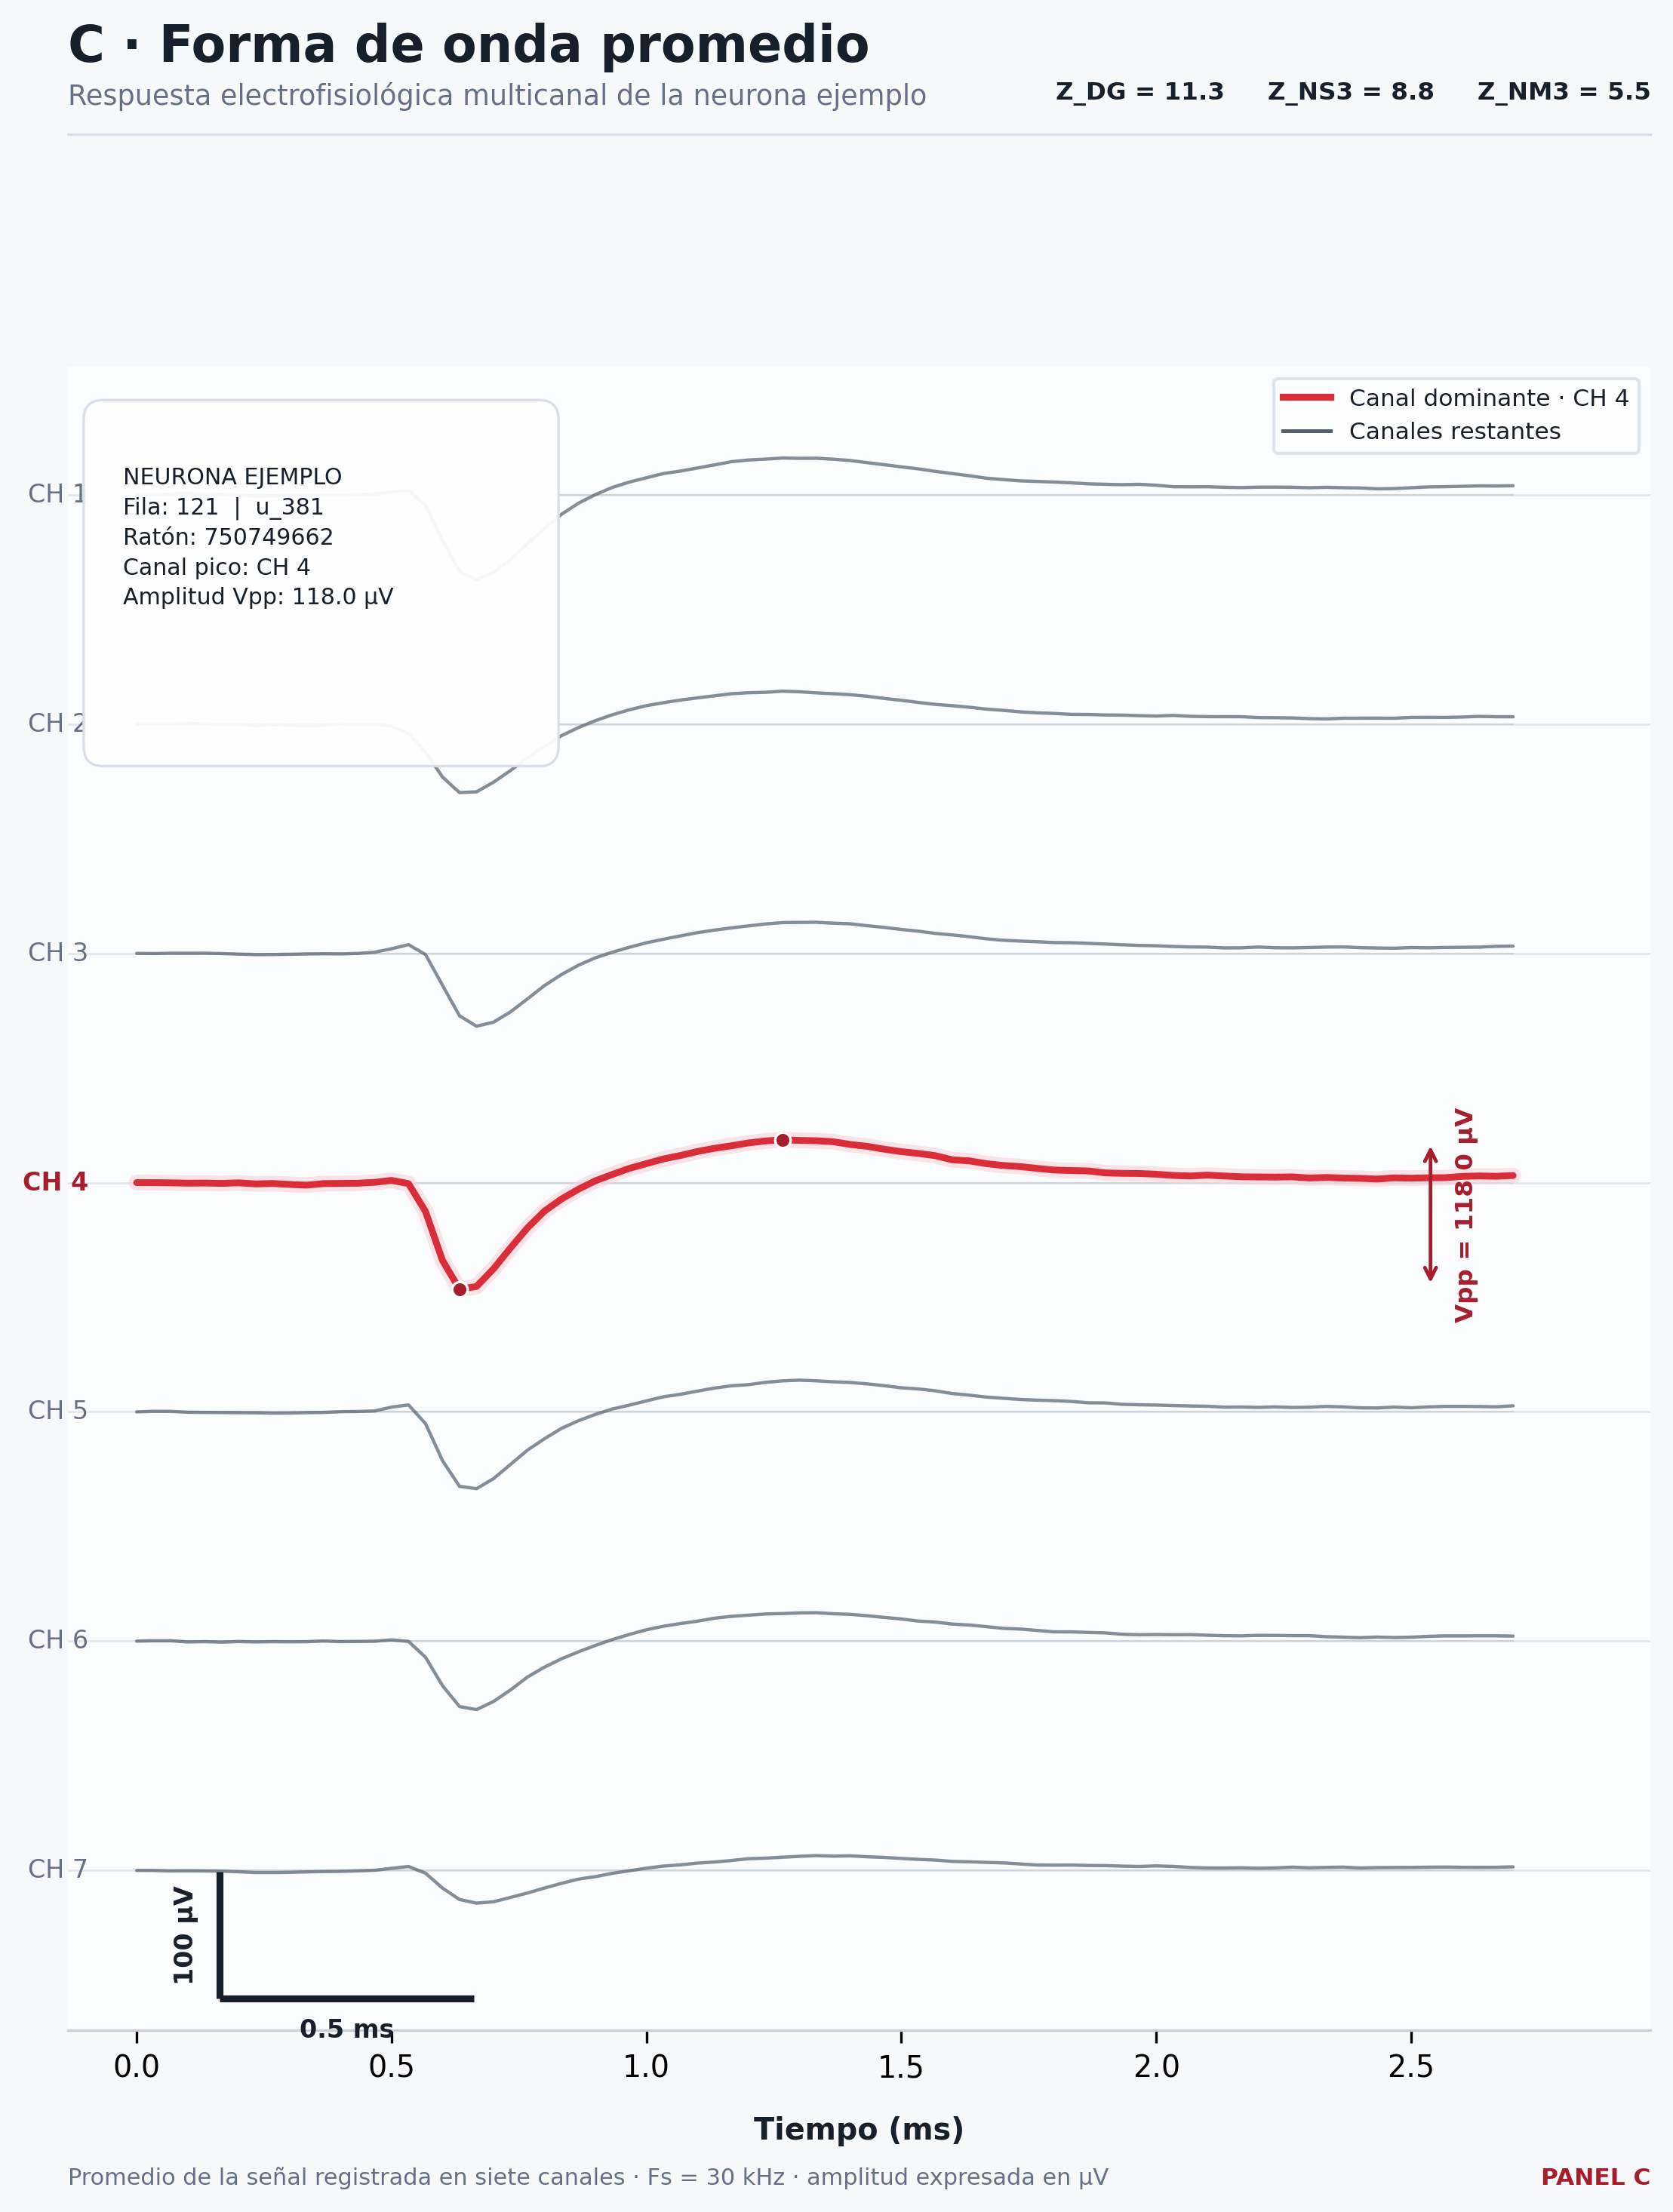

In [76]:
# ================================================================
# PANEL C — FORMA DE ONDA PROMEDIO (VERSIÓN DEFINITIVA Y PERFECCIONADA)
# ================================================================

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from matplotlib.patches import FancyBboxPatch

# ----------------------------------------------------------------
# 0. CONFIGURACIÓN Y PALETA
# ----------------------------------------------------------------
plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 9,
    "axes.linewidth": 0.8,
    "pdf.fonttype": 42,
    "ps.fonttype": 42,
})

BG              = "#F7F8FA"
PANEL           = "#FBFCFD"
TEXT            = "#17202A"
TEXT_SECONDARY = "#667085"
GRID            = "#D9DEE7"
ZERO            = "#AAB2BD"

CORAL           = "#D92D3A"
CORAL_DARK      = "#A61E2B"
CORAL_LIGHT     = "#F9D6DA"
CHANNEL         = "#52606D"

# ----------------------------------------------------------------
# 1. MATRIZ DE DATOS Y ESTADÍSTICAS
# ----------------------------------------------------------------
W = np.asarray(u_onda[EJ_U])
if W.ndim != 2:
    raise ValueError(f"La matriz debe ser 2D, se recibió: {W.shape}")

if W.shape[1] == 7:
    W = W.T

n_channels, n_samples = W.shape

# Tiempo (ms)
FS = 30_000
t_ms = np.arange(n_samples) * (1000 / FS)
duration_ms = t_ms[-1]

# Canal dominante y amplitudes
peak_to_peak = np.ptp(W, axis=1)
pico = int(np.argmax(peak_to_peak))

main_wave = W[pico]
main_max_idx, main_min_idx = np.argmax(main_wave), np.argmin(main_wave)
main_max, main_min = main_wave[main_max_idx], main_wave[main_min_idx]
main_vpp = main_max - main_min
main_max_t, main_min_t = t_ms[main_max_idx], t_ms[main_min_idx]

global_amplitude = np.max(np.abs(W))
sep = max(global_amplitude * 2.15, 1)

y_positions = -np.arange(n_channels) * sep
y_top = global_amplitude * 1.2
y_bottom = y_positions[-1] - global_amplitude * 1.5

# ----------------------------------------------------------------
# 2. FIGURA CON MÁRGENES PROPORCIONADOS
# ----------------------------------------------------------------
fig = plt.figure(figsize=(9.2, 10.5), dpi=300, facecolor=BG)

# Reducimos 'height' a 0.70 para garantizar aire limpio en la cabecera
ax = fig.add_axes([0.15, 0.10, 0.76, 0.70])
ax.set_facecolor(PANEL)

# Grids
for y in y_positions:
    ax.axhline(y, color=GRID, lw=0.7, alpha=0.65, zorder=0)
    ax.plot([t_ms[0], t_ms[-1]], [y, y], color=ZERO, lw=0.55, alpha=0.38, zorder=1)

# ----------------------------------------------------------------
# 3. DIBUJO DE TRAZAS
# ----------------------------------------------------------------
for c in range(n_channels):
    y_offset = y_positions[c]
    is_main = (c == pico)

    if is_main:
        ax.plot(t_ms, W[c] + y_offset, color=CORAL_LIGHT, lw=5.0, alpha=0.65, zorder=3, solid_capstyle="round")
        ax.plot(t_ms, W[c] + y_offset, color=CORAL, lw=2.15, zorder=5, solid_capstyle="round")
    else:
        ax.plot(t_ms, W[c] + y_offset, color=CHANNEL, lw=1.05, alpha=0.70, zorder=2, solid_capstyle="round")

    # Etiquetas CH fuera de la caja
    ax.text(-duration_ms * 0.035, y_offset, f"CH {c + 1}", ha="right", va="center",
            fontsize=8.0, fontweight="bold" if is_main else "normal",
            color=CORAL_DARK if is_main else TEXT_SECONDARY, clip_on=False)

# Picos positivo y negativo
main_y_offset = y_positions[pico]
ax.scatter([main_max_t, main_min_t], [main_max + main_y_offset, main_min + main_y_offset],
           s=24, color=CORAL_DARK, edgecolor="white", linewidth=0.8, zorder=10)

# Flecha e indicador Vpp
x_arrow = duration_ms * 0.94
ax.annotate("", xy=(x_arrow, main_max + main_y_offset), xytext=(x_arrow, main_min + main_y_offset),
            arrowprops=dict(arrowstyle="<->", color=CORAL_DARK, lw=1.15), zorder=8)
ax.text(x_arrow + duration_ms * 0.018, main_y_offset + (main_max + main_min) / 2,
        f"Vpp = {main_vpp:.1f} µV", fontsize=7.8, color=CORAL_DARK, fontweight="bold",
        va="center", rotation=90)

# ----------------------------------------------------------------
# 4. CAJA DE INFORMACIÓN DE LA NEURONA (DENTRO DEL AXES)
# ----------------------------------------------------------------
info_text = (
    f"NEURONA EJEMPLO\n"
    f"Fila: {EJ}  |  u_{EJ_U}\n"
    f"Ratón: {EJ_M}\n"
    f"Canal pico: CH {pico + 1}\n"
    f"Amplitud Vpp: {main_vpp:.1f} µV"
)

info_box = FancyBboxPatch((0.02, 0.77), 0.28, 0.20, transform=ax.transAxes,
                          boxstyle="round,pad=0.01,rounding_size=0.012",
                          linewidth=0.8, edgecolor="#D8DDE6", facecolor="#FFFFFF", alpha=0.94, zorder=20)
ax.add_patch(info_box)

ax.text(0.035, 0.94, info_text, transform=ax.transAxes, fontsize=7.2, color=TEXT,
        va="top", linespacing=1.45, zorder=21)

# ----------------------------------------------------------------
# 5. CABECERA Y TÍTULOS (EN ESPACIO LIBRE)
# ----------------------------------------------------------------
fig.text(0.15, 0.945, "C · Forma de onda promedio", fontsize=16, fontweight="bold", color=TEXT, va="top")
fig.text(0.15, 0.920, "Respuesta electrofisiológica multicanal de la neurona ejemplo", fontsize=8.8, color=TEXT_SECONDARY, va="top")

z_text = f"Z_DG = {Z['DG'][EJ]:.1f}     Z_NS3 = {Z['NS3'][EJ]:.1f}     Z_NM3 = {Z['NM3'][EJ]:.1f}"
fig.text(0.91, 0.920, z_text, fontsize=7.8, fontweight="bold", color=TEXT, ha="right", va="top")

fig.lines.append(Line2D([0.15, 0.91], [0.898, 0.898], transform=fig.transFigure, color="#D9DEE7", lw=0.8))

# ----------------------------------------------------------------
# 6. LEYENDA Y ESCALAS
# ----------------------------------------------------------------
legend_elements = [
    Line2D([0], [0], color=CORAL, lw=2.2, label=f"Canal dominante · CH {pico + 1}"),
    Line2D([0], [0], color=CHANNEL, lw=1.2, label="Canales restantes")
]
ax.legend(handles=legend_elements, loc="upper right", frameon=True, facecolor="#FFFFFF",
          edgecolor="#D8DDE6", fontsize=7.5, labelcolor=TEXT)

# Eje X y Límites
ax.set_yticks([])
ax.set_ylabel("")
ax.set_xlabel("Tiempo (ms)", fontsize=9.5, fontweight="bold", color=TEXT, labelpad=10)

ax.set_xlim(t_ms[0] - duration_ms * 0.05, t_ms[-1] + duration_ms * 0.10)
ax.set_ylim(y_bottom, y_top)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_color("#C8CED8")
ax.spines["bottom"].set_linewidth(0.8)

# Escala L profesional (Abajo a la izquierda)
scale_x = t_ms[0] + duration_ms * 0.06
scale_y = y_bottom + global_amplitude * 0.30
scale_time = 0.5  # ms
scale_uv = 100    # µV

ax.plot([scale_x, scale_x + scale_time], [scale_y, scale_y], color=TEXT, lw=2.2, solid_capstyle="butt", zorder=15)
ax.plot([scale_x, scale_x], [scale_y, scale_y + scale_uv], color=TEXT, lw=2.2, solid_capstyle="butt", zorder=15)

ax.text(scale_x + scale_time / 2, scale_y - global_amplitude * 0.18, f"{scale_time} ms",
        ha="center", va="top", fontsize=8, fontweight="bold", color=TEXT)
ax.text(scale_x - duration_ms * 0.015, scale_y + scale_uv / 2, f"{scale_uv} µV",
        ha="right", va="center", fontsize=8, fontweight="bold", color=TEXT, rotation=90)

# Pie
fig.text(0.15, 0.035, "Promedio de la señal registrada en siete canales · Fs = 30 kHz · amplitud expresada en µV",
         fontsize=7.3, color=TEXT_SECONDARY, ha="left")
fig.text(0.91, 0.035, "PANEL C", fontsize=7.5, fontweight="bold", color=CORAL_DARK, ha="right")

# Exportar
plt.savefig("Panel_C_Forma_de_Onda_PERFECTO.png", dpi=600, bbox_inches="tight", pad_inches=0.12)
plt.savefig("Panel_C_Forma_de_Onda_PERFECTO.svg", bbox_inches="tight", pad_inches=0.12)
plt.show()

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.ndimage import gaussian_filter1d

def figura_raster_psth(ej_u, ens_pref, t0, t1, bin_width, color_principal,
                        titulo, subtitulo, nombre_archivo):
    fig = plt.figure(figsize=(9.2, 10.5), dpi=300, facecolor="#F7F8FA")
    ax_raster = fig.add_axes([0.15, 0.48, 0.76, 0.32])
    ax_psth   = fig.add_axes([0.15, 0.10, 0.76, 0.32], sharex=ax_raster)
    ax_raster.set_facecolor("#FBFCFD"); ax_psth.set_facecolor("#FBFCFD")

    fig.text(0.15, 0.945, titulo, fontsize=16, fontweight="bold", color="#17202A", va="top")
    fig.text(0.15, 0.920, "Raster plot y PSTH de la respuesta en la condición preferida",
             fontsize=8.8, color="#667085", va="top")
    fig.text(0.91, 0.920, subtitulo, fontsize=8.0, fontweight="bold", color="#17202A", ha="right", va="top")
    fig.lines.append(Line2D([0.15, 0.91], [0.898, 0.898], transform=fig.transFigure, color="#D9DEE7", lw=0.8))

    num_ensayos = len(ens_pref)
    for i, ens in enumerate(ens_pref):
        spikes = s_t[(s_unidad == ej_u) & (s_ensayo == ens) & (s_t >= t0) & (s_t < t1)]
        ax_raster.vlines(spikes, i + 0.6, i + 1.4, color=color_principal, lw=0.85, alpha=0.85)

    ax_raster.axvline(0, color="#17202A", lw=0.9, linestyle="--", alpha=0.7)
    ax_raster.set_ylabel("Ensayo", fontsize=9.5, fontweight="bold", color="#17202A")
    ax_raster.set_ylim(0.5, num_ensayos + 0.5)
    ax_raster.set_yticks(np.arange(1, num_ensayos + 1))
    ax_raster.tick_params(axis="both", labelsize=8, colors="#667085")

    # tasa por ensayo, con la MISMA funcion conteos_bins ya definida y probada en la Parte 3
    conteos = conteos_bins(ens_pref, t0, t1, bin_width)[ej_u] / bin_width   # (num_ensayos, n_bins) Hz
    centros_bin = t0 + bin_width * (np.arange(conteos.shape[1]) + 0.5)
    tasa_media = conteos.mean(axis=0)
    sem_tasa = conteos.std(axis=0, ddof=1) / np.sqrt(num_ensayos)
    tasa_suave = gaussian_filter1d(tasa_media, sigma=0.8)
    sem_suave  = gaussian_filter1d(sem_tasa, sigma=0.8)

    ax_psth.plot(centros_bin, tasa_suave, color=color_principal, lw=2.0)
    ax_psth.fill_between(centros_bin, tasa_suave - sem_suave, tasa_suave + sem_suave,
                          color=color_principal, alpha=0.20, edgecolor="none")
    ax_psth.axvline(0, color="#17202A", lw=0.9, linestyle="--", alpha=0.7)
    ax_psth.set_xlabel("Tiempo desde el inicio (s)", fontsize=9.5, fontweight="bold", color="#17202A", labelpad=8)
    ax_psth.set_ylabel("Tasa (Hz)", fontsize=9.5, fontweight="bold", color="#17202A")
    ax_psth.grid(axis="y", color="#D9DEE7", linestyle=":", lw=0.6, alpha=0.7)

    plt.setp(ax_raster.get_xticklabels(), visible=False)
    for ax in [ax_raster, ax_psth]:
        ax.spines["top"].set_visible(False); ax.spines["right"].set_visible(False)
        ax.spines["left"].set_color("#C8CED8"); ax.spines["bottom"].set_color("#C8CED8")
        ax.tick_params(colors="#667085")
    ax_raster.spines["bottom"].set_visible(False)

    fig.text(0.15, 0.035, "Espigas alineadas al inicio del ensayo (0 s) y promediadas sobre los ensayos registrados",
             fontsize=7.3, color="#667085", ha="left")
    fig.text(0.91, 0.035, "PANEL D", fontsize=7.5, fontweight="bold", color="#A61E2B", ha="right")

    plt.savefig(nombre_archivo, dpi=600, bbox_inches="tight", pad_inches=0.12)
    plt.show()

print("figura_raster_psth lista (version completa, sin referencias indefinidas).")

In [ ]:
# ===== FIGURA 1, PANEL D — rejillas en movimiento, condicion preferida =====
e_dg = ensayos_de(DG, EJ_M); lab = etiqueta_dg(e_dg)
R = POR_RATON[EJ_M]; fila = np.where(R["neu"] == EJ_U)[0][0]
pref = np.argmax(medias_cond(*R["DG"])[fila])
ens_pref_dg = e_dg[lab == pref]
t0dg, t1dg = max(RANGO[DG][0], -0.5), min(RANGO[DG][1], 2.5)

figura_raster_psth(EJ_U, ens_pref_dg, t0dg, t1dg, 0.05, CORAL,
    "D · Rejillas en movimiento",
    f"{e_ori[ens_pref_dg[0]]:.0f}\u00b0, {e_tf[ens_pref_dg[0]]:.0f} Hz  ·  Z = {Z['DG'][EJ]:.1f}",
    "Panel_D_Rejillas.png")

# ===== FIGURA 1, PANEL D\' — pelicula natural, 8 pasadas =====
e_nm = ensayos_de(NM, EJ_M); e_nm = e_nm[np.argsort(e_t0[e_nm])]

figura_raster_psth(EJ_U, e_nm, 0, 30, 0.25, AZUL,
    "D\u2032 · Película natural",
    f"8 pasadas de 30 s  ·  Z = {Z['NM3'][EJ]:.1f}",
    "Panel_D_prima_Pelicula.png")

### Revisión del umbral (mirar, no calcular)
Rasters de película de 3 neuronas justo por encima y 3 justo por debajo del umbral. Si las de abajo claramente responden, o las de arriba no, el umbral se discute en métodos (falsos negativos / positivos).

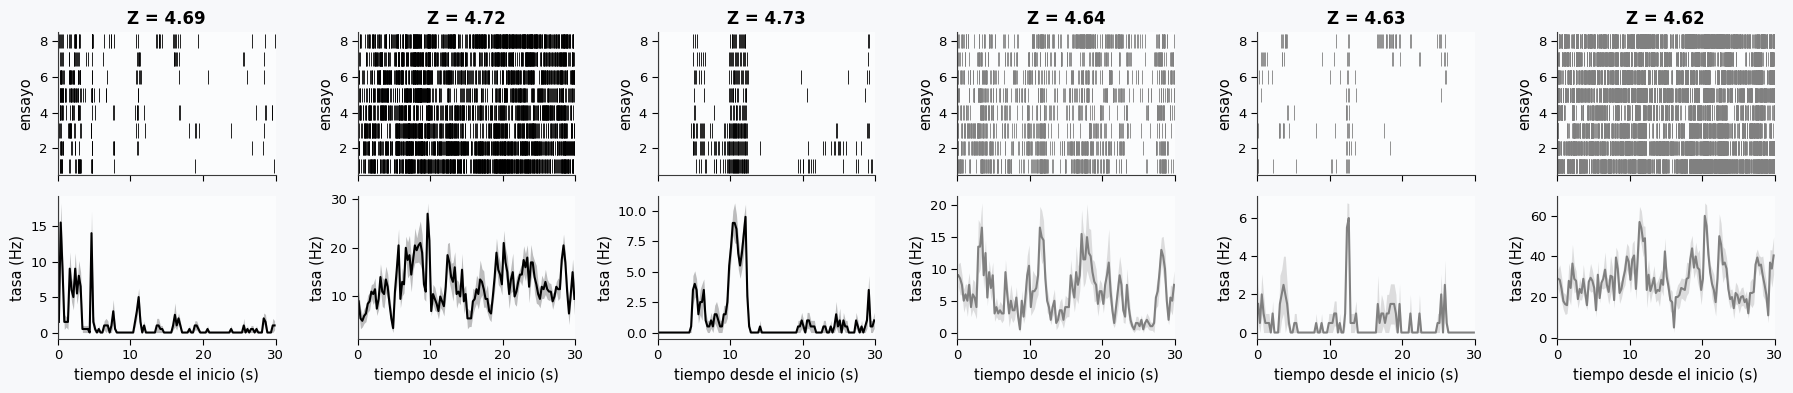

In [82]:
orden = np.argsort(np.abs(Z["NM3"] - UMBRAL_COMP))
arriba = [i for i in orden if Z["NM3"][i] >= UMBRAL_COMP][:3]; abajo = [i for i in orden if Z["NM3"][i] < UMBRAL_COMP][:3]
fig, axs = plt.subplots(2, 6, figsize=(18, 4), sharex=True)
for j, i in enumerate(arriba + abajo):
    raster_psth(axs[0, j], axs[1, j], NEU_ORDEN[i], ensayos_de(NM, RATON_DE[i]), 0, 30, ANCHO,
                color="k" if Z["NM3"][i] >= UMBRAL_COMP else "0.5", titulo=f"Z = {Z['NM3'][i]:.2f}")
plt.tight_layout(); plt.show()

### Figura 2
- **A** PSTH poblacional a rejillas en movimiento: por neurona se promedia sobre los ensayos de su ratón; después media ± EE entre neuronas. Todas las neuronas y solo las respondedoras.
- **B** PSTH por clase, agrupando estímulos de la misma duración: 2 s (rejillas en movimiento, espontáneo), 0,25 s (rejillas estáticas, escenas, destellos), 30 s (película, sola).
- **C** Mapa de calor: Z de la tasa media sobre **todos** los ensayos de cada clase (sin escoger condición preferida, para que columnas con 2 o con 120 condiciones sean comparables), con la basal de la misma ventana. Filas ordenadas por ratón y por Z de rejillas.
- **D** Enjambre del Z (condición preferida) en escenas y película, con el umbral.
- **E** Fracción respondedora por ratón (líneas grises), total con IC jerárquico, p y d.

## Figura 2 — cada panel en su propio archivo, misma paleta que la Figura 1

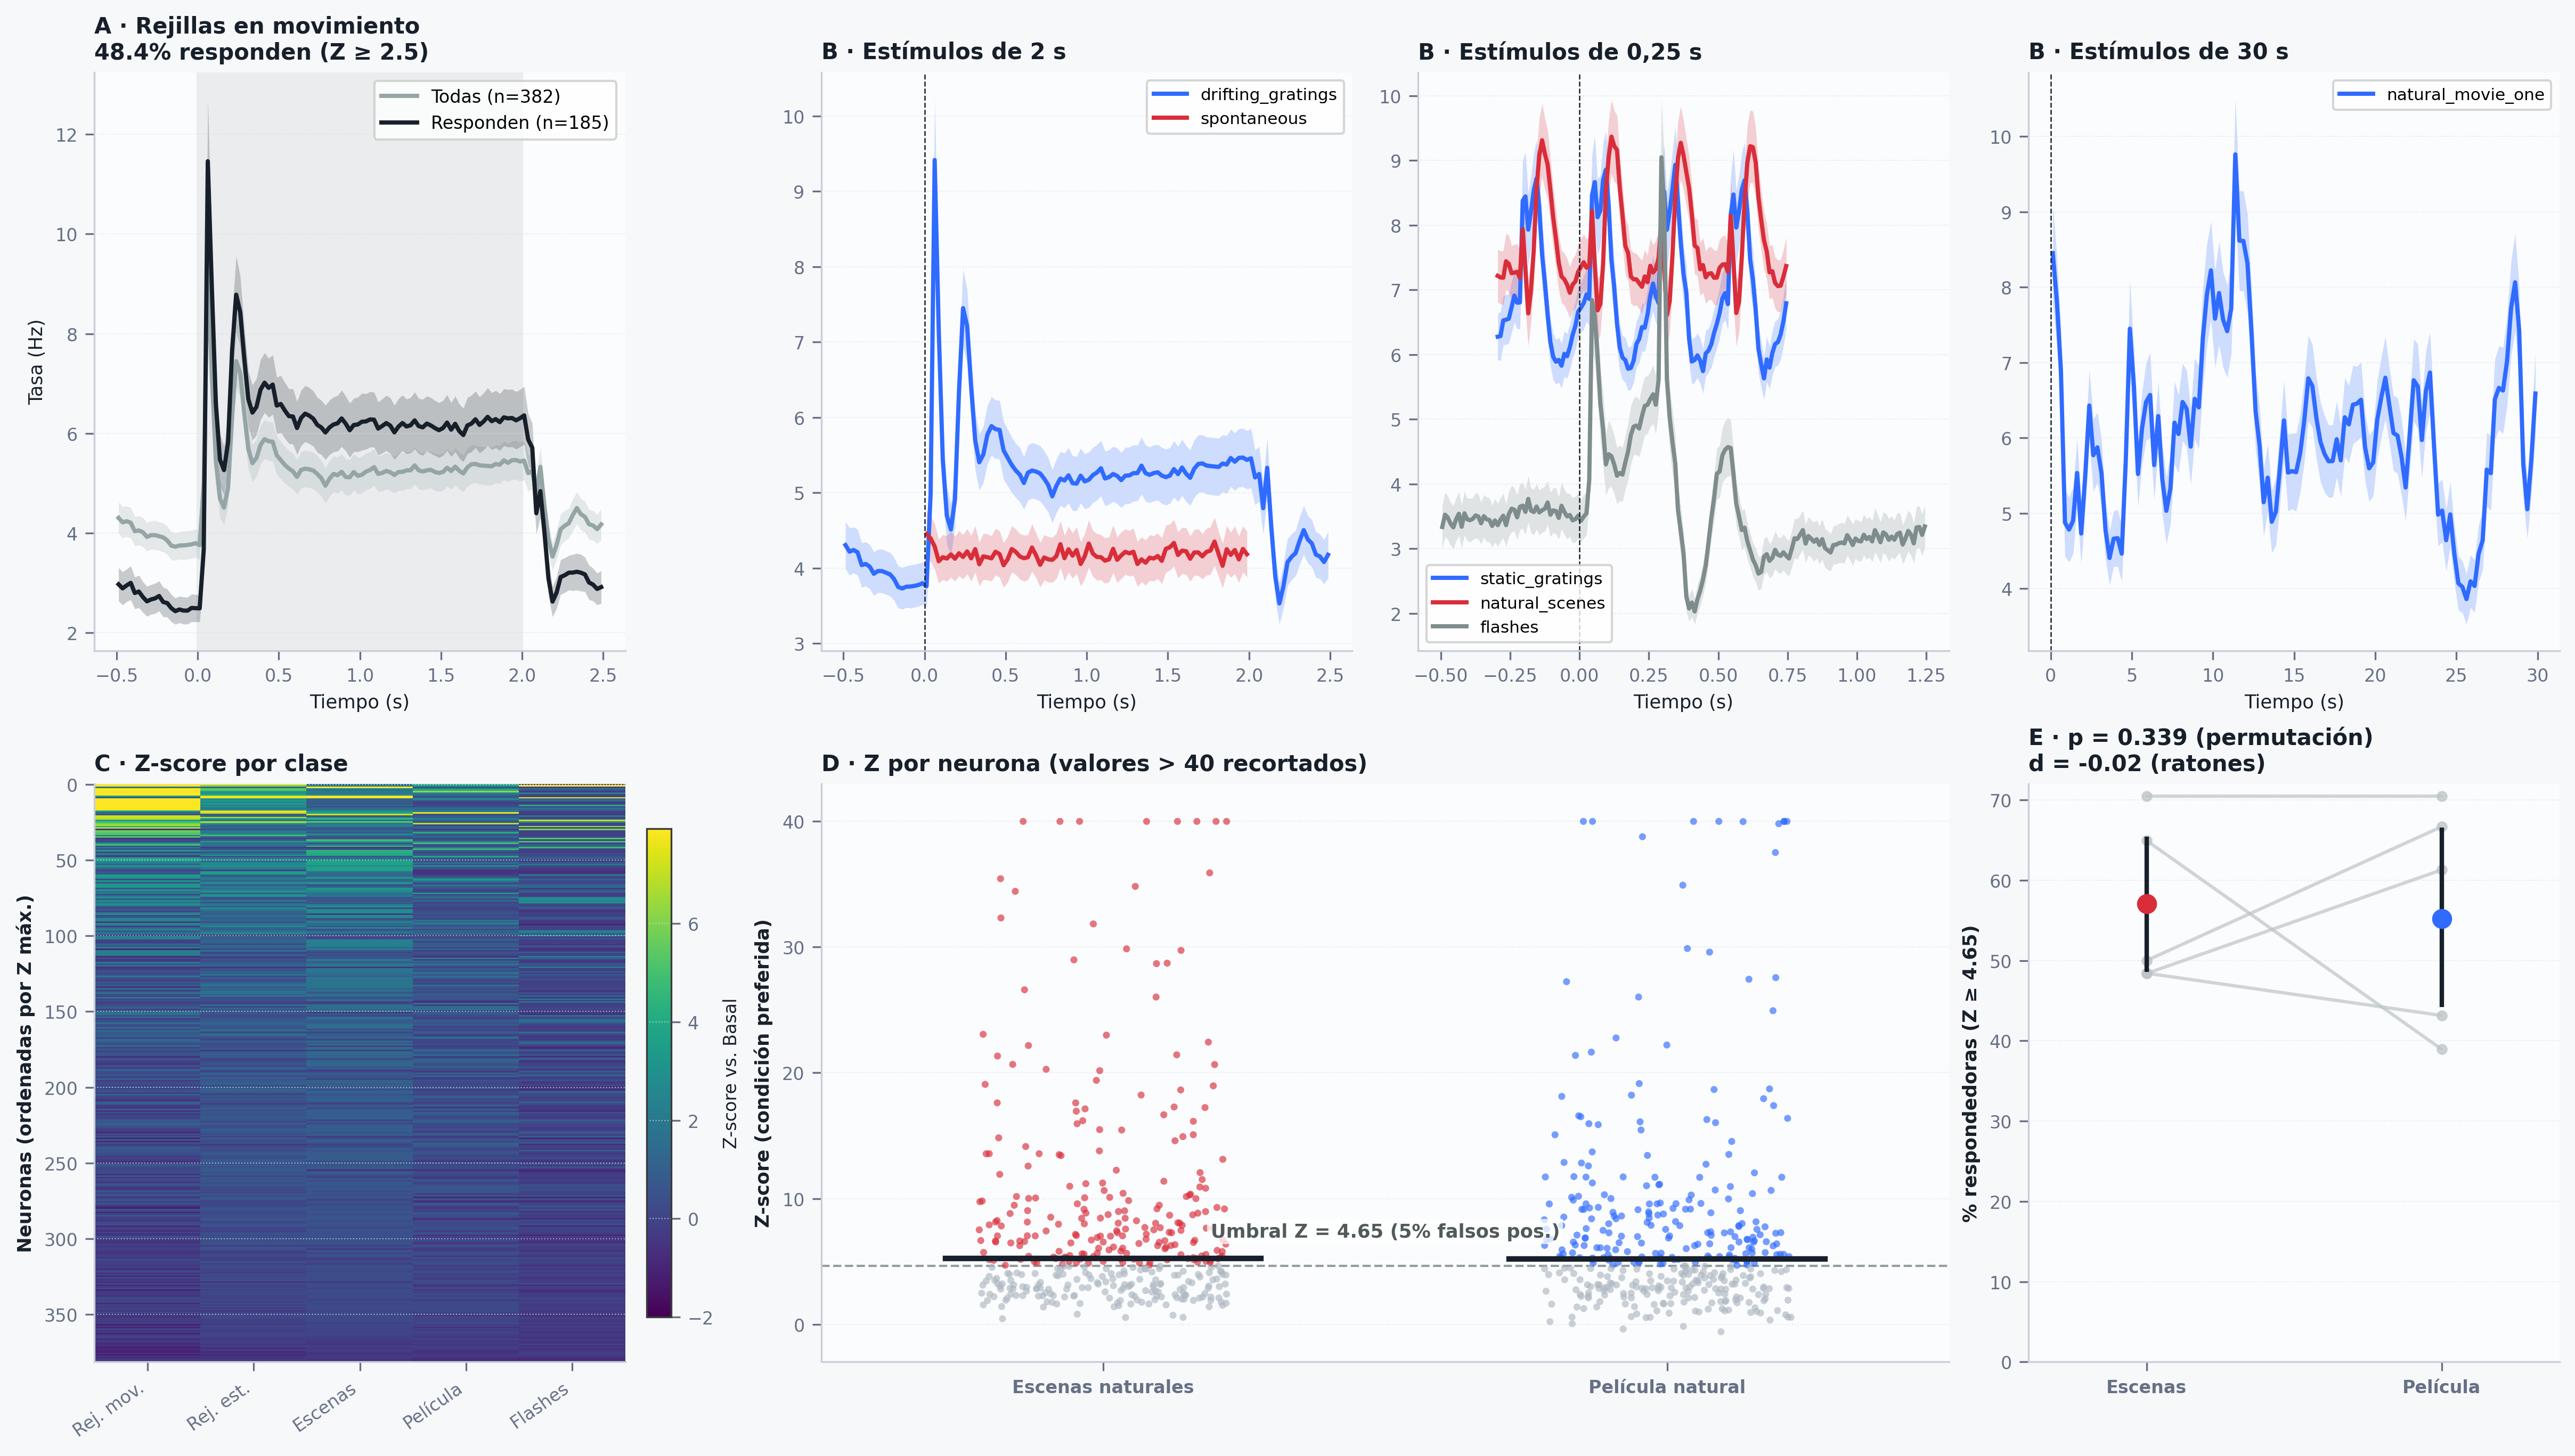

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# --- ESTILOS Y COLORES GLOBALES ---
AZUL = "#2F6BFF"
CORAL = "#D92D3A"
NEUTRAL = "#AEB8C2"
TEXTO = "#17202A"
GRIS_LINEA = "#D9DEE7"

# constrained_layout=True calcula el espaciado solo -- por eso el gridspec de abajo
# ya NO lleva hspace/wspace manuales (mezclar los dos fue lo que abría esos huecos enormes)
fig = plt.figure(figsize=(16, 9), dpi=300, facecolor="#F7F8FA", constrained_layout=True)
gs = fig.add_gridspec(2, 4)

# ================================================================
# PANEL A · Rejillas en movimiento
# ================================================================
ax_a = fig.add_subplot(gs[0, 0])
ax_a.set_facecolor("#FBFCFD")

x, P = psth_pob(DG, t0dg, t1dg, 0.025)
trazar(ax_a, x, P, f"Todas (n={len(P)})", "#95A5A6")
trazar(ax_a, x, P[resp_dg], f"Responden (n={resp_dg.sum()})", TEXTO)

ax_a.axvspan(*VENT_DG, color="#EAECEE", zorder=0)
ax_a.legend(fontsize=8, frameon=True, facecolor="#FFFFFF")
ax_a.set_title(f"A · Rejillas en movimiento\n{resp_dg.mean()*100:.1f}% responden (Z ≥ {UMBRAL})",
               loc="left", fontsize=10, fontweight="bold", color=TEXTO)
ax_a.set_xlabel("Tiempo (s)", fontsize=8.5, color=TEXTO)
ax_a.set_ylabel("Tasa (Hz)", fontsize=8.5, color=TEXTO)

# ================================================================
# PANEL B · Estímulos por ventana temporal
# ================================================================
grupos = [("2 s", [(DG, t0dg, t1dg), (ESP, 0, 2)], 0.025),
          ("0,25 s", [(SG, RANGO[SG][0], RANGO[SG][1]), (NS, RANGO[NS][0], RANGO[NS][1]), (FL, RANGO[FL][0], RANGO[FL][1])], 0.01),
          ("30 s", [(NM, 0, 30)], 0.25)]
colores_b = [AZUL, CORAL, "#7F8C8D"]

for j, (nombre, lista, ancho) in enumerate(grupos):
    ax_b = fig.add_subplot(gs[0, j + 1])
    ax_b.set_facecolor("#FBFCFD")
    for (c, a, b), col in zip(lista, colores_b):
        x_b, P_b = psth_pob(c, a, b, ancho)
        trazar(ax_b, x_b, P_b, c, col)
    ax_b.axvline(0, color=TEXTO, lw=0.6, ls="--")
    ax_b.legend(fontsize=7.5, frameon=True, facecolor="#FFFFFF")
    ax_b.set_title(f"B · Estímulos de {nombre}", loc="left", fontsize=10, fontweight="bold", color=TEXTO)
    ax_b.set_xlabel("Tiempo (s)", fontsize=8.5, color=TEXTO)

# ================================================================
# PANEL C · Mapa de Calor (Viridis + Ordenamiento Global)
# ================================================================
ax_c = fig.add_subplot(gs[1, 0])
ax_c.set_facecolor("#FBFCFD")

cols = ["DG", "SG", "NS", "NM", "FL"]
H_raw = np.column_stack([ZT[k] for k in cols])

z_max_neurona = np.nanmax(H_raw, axis=1)
orden_global = np.argsort(-z_max_neurona)
H_ordenado = H_raw[orden_global]

vmax_c = max(3, np.nanpercentile(H_ordenado, 99))
im = ax_c.imshow(np.clip(H_ordenado, -2, vmax_c), aspect="auto", cmap="viridis", vmin=-2, vmax=vmax_c, interpolation="nearest")

ax_c.set_xticks(range(len(cols)))
ax_c.set_xticklabels(["Rej. mov.", "Rej. est.", "Escenas", "Película", "Flashes"], rotation=35, ha="right", fontsize=8.5)
ax_c.set_ylabel("Neuronas (ordenadas por Z máx.)", fontsize=8.5, fontweight="bold", color=TEXTO)
ax_c.set_title("C · Z-score por clase", loc="left", fontsize=10, fontweight="bold", color=TEXTO)

cb = plt.colorbar(im, ax=ax_c, fraction=0.046, pad=0.04)
cb.set_label("Z-score vs. Basal", fontsize=8, color=TEXTO)

# ================================================================
# PANEL D · Enjambre de Z por Neurona (2 columnas de ancho)
# ================================================================
ax_d = fig.add_subplot(gs[1, 1:3])
ax_d.set_facecolor("#FBFCFD")

rng_j = np.random.default_rng(0)
condiciones_d = [("NS3", "Escenas naturales", CORAL), ("NM3", "Película natural", AZUL)]

for i, (k, nombre, color) in enumerate(condiciones_d):
    z = np.clip(np.nan_to_num(Z[k], posinf=40), None, 40)
    jitter = rng_j.uniform(-0.22, 0.22, len(z))
    colores_pt = np.where(z >= UMBRAL_COMP, color, NEUTRAL)

    ax_d.scatter(i + jitter, z, s=10, c=colores_pt, alpha=0.65, linewidths=0, zorder=3)
    mediana = np.median(z)
    ax_d.plot([i - 0.28, i + 0.28], [mediana, mediana], color=TEXTO, lw=2.5, zorder=4)

ax_d.axhline(UMBRAL_COMP, color="#7F8C8D", ls="--", lw=1, alpha=0.85, zorder=2)
# Umbral centrado arriba de la linea, con fondo blanco para que se lea encima de los puntos
ax_d.text(0.5, UMBRAL_COMP + 2, f"Umbral Z = {UMBRAL_COMP:.2f} (5% falsos pos.)",
          va="bottom", ha="center", fontsize=8.5, color="#515A5A", fontweight="bold",
          bbox=dict(facecolor="white", edgecolor="none", alpha=0.75, pad=1.5))

ax_d.set_xticks([0, 1])
ax_d.set_xticklabels([c[1] for c in condiciones_d], fontsize=9.5, fontweight="bold", color=TEXTO)
ax_d.set_xlim(-0.5, 1.5)
ax_d.set_ylim(-3, 43)
ax_d.set_ylabel("Z-score (condición preferida)", fontsize=8.5, fontweight="bold", color=TEXTO)
ax_d.set_title("D · Z por neurona (valores > 40 recortados)", loc="left", fontsize=10, fontweight="bold", color=TEXTO)

# ================================================================
# PANEL E · Proporción de Neuronas que Responden
# ================================================================
ax_e = fig.add_subplot(gs[1, 3])
ax_e.set_facecolor("#FBFCFD")

for m in RATONES:
    ax_e.plot([0, 1], [frac_raton[m][0] * 100, frac_raton[m][1] * 100], "-o", color="#BDC3C7", ms=4, alpha=0.7)

for i, (k, f, col) in enumerate([("NS3", f_ns, CORAL), ("NM3", f_nm, AZUL)]):
    ax_e.plot(i, f * 100, "o", color=col, ms=8, zorder=4)
    ax_e.vlines(i, IC[k][0] * 100, IC[k][1] * 100, color=TEXTO, lw=2, zorder=3)

ax_e.set_xticks([0, 1])
ax_e.set_xticklabels(["Escenas", "Película"], fontsize=9.5, fontweight="bold", color=TEXTO)
ax_e.set_xlim(-0.4, 1.4)
ax_e.set_ylim(0, None)
ax_e.set_ylabel(f"% respondedoras (Z ≥ {UMBRAL_COMP:.2f})", fontsize=8.5, fontweight="bold", color=TEXTO)
ax_e.set_title(f"E · p = {p_perm:.3g} (permutación)\nd = {d_raton:.2f} (ratones)", loc="left", fontsize=10, fontweight="bold", color=TEXTO)

# --- FORMATO GENERAL DE SPINES Y GRID ---
for ax in fig.axes:
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_color("#C8CED8")
    ax.spines["bottom"].set_color("#C8CED8")
    ax.tick_params(colors="#667085", labelsize=8)
    ax.grid(axis="y", color="#D9DEE7", linestyle=":", lw=0.5, alpha=0.7)

plt.savefig("figura2_completa_corregida.png", dpi=600, bbox_inches="tight")
plt.show()

---
## Parte 8 · Números para el texto
Esta celda imprime todo lo que va en métodos y resultados. Copien de aquí, no de celdas viejas.

In [97]:
print(f"""
EJE COMÚN (rejillas en movimiento vs espontáneo): {resp_dg.mean()*100:.1f} % ({resp_dg.sum()}/{N_U}),
  IC95 jerárquico [{IC['DG'][0]*100:.1f}, {IC['DG'][1]*100:.1f}] % (crudo [{IC_CRUDO['DG'][0]*100:.1f}, {IC_CRUDO['DG'][1]*100:.1f}]), rango entre ratones {min(frac_dg_raton.values())*100:.1f}-{max(frac_dg_raton.values())*100:.1f} %.

ESCENAS (3 rep.): {f_ns*100:.1f} % ({resp_ns.sum()}/{N_U}), IC95 [{IC['NS3'][0]*100:.1f}, {IC['NS3'][1]*100:.1f}] %
PELÍCULA (3 pasadas): {f_nm*100:.1f} % ({resp_nm.sum()}/{N_U}), IC95 [{IC['NM3'][0]*100:.1f}, {IC['NM3'][1]*100:.1f}] %
DIFERENCIA (película - escenas): {d_obs*100:+.1f} pts, IC95 [{IC['dif'][0]*100:+.1f}, {IC['dif'][1]*100:+.1f}], p = {p_perm:.3g} (permutación de ensayos dentro de neurona, {N_PERM} barajadas)
d de Cohen: {d_raton:+.2f} (unidad ratón, n = 5); {d_neur:+.2f} (unidad neurona)
Falsos positivos esperados por diseño (igualado): escenas {FP['NS3'][0]*100:.1f} %, película {FP['NM3'][0]*100:.1f} %, rejillas {FP['DG'][0]*100:.1f} %
UMBRAL comparación asignada: Z >= {UMBRAL_COMP:.2f} (percentil 95 del nulo); con Z >= {UMBRAL}: escenas {np.mean(Z['NS3'] >= UMBRAL)*100:.1f} %, película {np.mean(Z['NM3'] >= UMBRAL)*100:.1f} %, falsos positivos {fp('NS3', UMBRAL).mean()*100:.0f} %
Todas las repeticiones (sesgado): escenas {np.mean(Z['NS'] >= UMBRAL_COMP)*100:.1f} %, película {np.mean(Z['NM'] >= UMBRAL_COMP)*100:.1f} %
Película promediando los subconjuntos de {N_REP} pasadas: {f_nm_subconj*100:.1f} %
t emparejado ignorando ratón: p = {t_ing.pvalue:.2g}
""")


EJE COMÚN (rejillas en movimiento vs espontáneo): 48.4 % (185/382),
  IC95 jerárquico [42.2, 54.9] % (crudo [42.5, 55.2]), rango entre ratones 41.7-54.5 %.

ESCENAS (3 rep.): 57.1 % (218/382), IC95 [48.6, 65.4] %
PELÍCULA (3 pasadas): 55.2 % (211/382), IC95 [44.2, 66.5] %
DIFERENCIA (película - escenas): -1.8 pts, IC95 [-14.3, +11.0], p = 0.339 (permutación de ensayos dentro de neurona, 10000 barajadas)
d de Cohen: -0.02 (unidad ratón, n = 5); -0.03 (unidad neurona)
Falsos positivos esperados por diseño (igualado): escenas 5.0 %, película 5.1 %, rejillas 0.0 %
UMBRAL comparación asignada: Z >= 4.65 (percentil 95 del nulo); con Z >= 2.5: escenas 83.8 %, película 81.7 %, falsos positivos 34 %
Todas las repeticiones (sesgado): escenas 55.2 %, película 40.6 %
Película promediando los subconjuntos de 3 pasadas: 49.3 %
t emparejado ignorando ratón: p = 0.53



---
## Plantilla de métodos (llenar con los números de la parte 8)
**Datos.** Registros extracelulares con sondas Neuropixels del Allen Brain Observatory, Visual Coding Neuropixels (Siegle et al. 2021). Unidades separadas con Kilosort2 por el Allen Institute y ya filtradas por calidad. 382 unidades de VISp en 5 ratones (una sesión por ratón). No se aplicó filtro adicional.

**Tasas y ventanas.** Rejillas en movimiento: PAs entre 0 y 2 s desde el inicio. Escenas naturales: 0-0,25 s. Película natural: cada pasada de 30 s dividida en 120 trozos de 0,25 s; cada trozo se trató como una condición, igual que cada imagen. Basal: pantalla gris (espontáneo), 150 trozos de 2 s por ratón, con la misma ventana que la evocada (2 s, u 8 sub-ventanas de 0,25 s). Cada neurona se analizó solo con los ensayos de su ratón.

**Criterio de respuesta.** Z = (tasa media en la condición preferida − media basal) / DE basal. Condición preferida: la de mayor tasa media (rejillas: dirección × frecuencia temporal × frecuencia espacial, sin barridos en blanco; escenas: imagen; película: trozo). Rejillas en movimiento (eje común): responde si Z ≥ 2,5, el umbral acordado en el curso (falsos positivos esperados ≈ __ %). Escenas y película: con ventanas de 0,25 s y 3 repeticiones, Z ≥ 2,5 dejaba pasar ≈ __ % de neuronas en un control sin estímulo (espontáneo repartido en el mismo diseño), así que el umbral se fijó en el percentil 95 de ese Z nulo (Z ≥ __), el mismo para los dos estímulos. Para comparar escenas y película se usaron las 3 primeras repeticiones de cada imagen y de cada trozo (3 primeras pasadas), porque con repeticiones desiguales el máximo entre condiciones favorece al estímulo con menos repeticiones.

**Estadística.** Fracción respondedora = respondedoras / total de neuronas (todas las neuronas juntas). IC del 95 %: bootstrap jerárquico de 10 000 réplicas, con reemplazo en tres niveles (ratones; neuronas dentro de cada ratón; ensayos de la condición preferida y trozos de espontáneo dentro de cada neurona), condición preferida fija, percentiles 2,5-97,5 corregidos por el sesgo del bootstrap. Valor p: permutación de 10 000 barajadas de los ensayos entre escenas y película dentro de cada neurona, re-escogiendo la condición preferida en cada barajada. d de Cohen: diferencia media película − escenas entre los 5 ratones dividida por su DE. Comparación: IC de t que trata a cada neurona como independiente. Python 3 (NumPy, SciPy, Matplotlib), código en GitHub: ____.

**Uso del modelo de lenguaje.** Qué se le pidió, qué devolvió mal y cómo se corrigió (p. ej.: bootstrap sin nivel de ratón; no emparejar ratones; re-escoger la condición preferida dentro del bootstrap).

**Cita de los datos.** Siegle JH et al. (2021). Survey of spiking in the mouse visual system reveals functional hierarchy. *Nature* 592, 86-92.

---
## Prompt para generar los Paneles A y B (esquemas, sin cálculo)

Copien esto en Claude (o en Claude para PowerPoint) para generar los dos esquemas — el enunciado pide que queden claros, no que sean elaborados:

> Necesito dos esquemas simples y claros para el Panel A y el Panel B de un póster científico de neurociencia (no tienen que ser artísticos, solo claros y correctos).
>
> **Panel A — esquema del experimento:** un ratón fijado de cabeza sobre una plataforma que gira, mirando una pantalla que muestra rejillas en blanco y negro, con una sonda Neuropixels insertada en el cerebro conectada a un cable de grabación. Etiqueten: "ratón", "pantalla", "sonda Neuropixels", y el área grabada "VISp (corteza visual primaria)".
>
> **Panel B — esquema del estímulo y las condiciones asignadas:** una línea de tiempo mostrando (1) una rejilla en movimiento con flecha de dirección, duración 2 s; (2) debajo, dos recuadros comparando "película natural" (un ícono de película, 30 s, 8 repeticiones) contra "escenas naturales" (una foto en blanco y negro, 0,25 s, ~3-4 repeticiones por imagen). Usen texto simple para las duraciones y repeticiones. Blanco y negro o escala de grises, estilo diagrama técnico, sin decoración innecesaria.
>
> Formato: una diapositiva de PowerPoint por panel, fondo blanco, texto en Arial u otra fuente sans-serif, sin colores llamativos (el póster es en blanco y negro).